---

[![Abrir no Google Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ppestana-supervisor/PDI_python/blob/main/topico4/notebook42.ipynb)

> **Nota importante**
>
> Este notebook é carregado diretamente a partir do repositório oficial no GitHub e é apenas para **leitura**.  
> As alterações **não ficam guardadas**.
>
> Para guardar uma versão pessoal:
> - No Colab, ir a **Ficheiro → Guardar uma cópia no Drive**.  
> - A cópia ficará disponível em `O meu Drive / Colab Notebooks`.
>
> Para colaboração:
> - Abrir a versão pessoal no Google Drive.  
> - Clicar em **Partilhar** → **Qualquer pessoa com o link pode editar** (ou adicionar os colegas manualmente).  
> - A partir daí, todos podem editar em tempo real, como num Google Docs.
>
> Para guardar resultados (imagens, ficheiros, etc.) no  Drive:
> ```python
> from google.colab import drive
> drive.mount('/content/drive')
> ```
> Depois gravar, por exemplo, em:
> ```python
> img.save('/content/drive/MyDrive/PDI_outputs/resultado.png')
> ```

---

In [ ]:
### !!! Executar esta célula primeiro, se dentro do Colab
# Quando dentro do Colab, clonar o repositório completo para garantir acesso à pasta de imagens
!git clone https://github.com/ppestana-supervisor/PDI_python.git
%cd PDI_python/topico4

# 4.2 Deteção de Arestas e Contornos

A **deteção de arestas** é um passo crucial na análise estrutural de imagens, permitindo identificar as transições abruptas de intensidade que correspondem frequentemente a fronteiras entre objetos ou regiões. As arestas marcam zonas de variação significativa no brilho local, constituindo uma das formas mais diretas de representar a **estrutura geométrica** de uma cena.

Matematicamente, uma aresta corresponde a uma **variação espacial do gradiente** da imagem — isto é, ao módulo da derivada em relação às direções $x$ e $y$:

$$
\nabla f(x, y) = 
\left(
\frac{\partial f}{\partial x},
\frac{\partial f}{\partial y}
\right),
\qquad
|\nabla f(x, y)| = \sqrt{
\left(\frac{\partial f}{\partial x}\right)^2 + 
\left(\frac{\partial f}{\partial y}\right)^2
}
$$

onde $|\nabla f(x, y)|$ representa a intensidade da aresta e o ângulo do vetor gradiente define a sua orientação.

Na prática, as derivadas são aproximadas por **máscaras de convolução discretas**, como as de **Sobel**, **Prewitt** ou **Roberts**, que realçam as direções horizontal e vertical. Estes operadores permitem calcular, ponto a ponto, a magnitude do gradiente e criar uma imagem binária que destaca as zonas de transição mais fortes.  

A partir das arestas, é possível extrair **contornos** — linhas contínuas que delimitam os objetos — utilizando técnicas de seguimento (*edge tracing*) ou algoritmos mais elaborados, como o **Canny**, que combina filtragem, supressão de não-máximos e histerese para produzir resultados robustos.

Em termos conceituais:
- A **deteção de arestas** identifica os locais de variação rápida da intensidade.
- A **extração de contornos** liga essas arestas de forma coerente, descrevendo os limites das formas presentes na imagem.

Neste capítulo, são exploradas várias abordagens, desde as implementações manuais de operadores diferenciais até ao uso de filtros compostos e métodos clássicos de segmentação baseados em gradiente. Tal como nos restantes módulos, a prioridade é **compreender o princípio operativo**: por isso, as funções das bibliotecas são substituídas por **reimplementações simplificadas e pedagógicas**, que revelam o funcionamento interno dos algoritmos e as suas limitações práticas.

## 4.2.1. Importar bibliotecas essenciais

Nesta célula inicial são carregadas as principais bibliotecas necessárias para o processamento e análise de imagens no notebook. Tal como nas células equivalentes de outros capítulos, esta define o ambiente de trabalho e as imagens de base — tanto sintéticas como reais — que serão utilizadas para demonstrar operações de deteção de arestas e contornos.

#### Bibliotecas

**NumPy** é usada para manipulação matricial e criação de padrões sintéticos.  
**OpenCV (cv2)** é utilizada para desenhar formas geométricas (linhas, retângulos) e para operações de processamento de imagem eficientes.  
**Matplotlib** fornece as ferramentas de visualização e controlo estético das figuras.  
**Pillow (PIL)** é usada para carregar imagens externas e convertê-las em tons de cinzento.  
O módulo **scikit-image** disponibiliza funções para análise e filtragem (`filters`), medição e rotulagem de regiões (`measure`), e conversão de cores (`color`), bem como um conjunto de imagens de exemplo (`data`).  
A biblioteca **SciPy** é utilizada aqui pelo seu módulo `ndimage`, que contém funções de filtragem espacial, nomeadamente o filtro gaussiano.  
Por fim, a biblioteca **time** permite medir tempos de execução em blocos de código experimentais.

#### Criação de Imagens Sintéticas

São geradas três imagens artificiais, úteis para testar algoritmos de deteção de contornos e transformações morfológicas:
- `img_squares`: composta por dois quadrados concêntricos com tons distintos (fundo cinzento, quadrado branco e quadrado interno preto), ideal para observar efeitos de gradientes e bordas múltiplas.
- `img_lines`: inclui duas linhas diagonais com espessuras e intensidades diferentes, simulando arestas orientadas e contrastes variáveis.
- `img_rect`: contém um único retângulo de contorno fino sobre fundo preto, servindo como caso de referência simples para detetores de arestas.

#### Imagens Importadas

`img_coins` é uma imagem clássica do **scikit-image**, amplamente usada em exemplos de segmentação e deteção de bordas devido à presença de objetos parcialmente sobrepostos.  
`img_building` é um ficheiro externo carregado da pasta `imgs/`, convertido para tons de cinzento através de Pillow. Contém estruturas arquitetónicas bem definidas, ideais para avaliar o comportamento de filtros direcionais e gradientes sobre linhas retas e padrões estruturados.

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from skimage import  data, img_as_float, filters, measure, color
from scipy.ndimage import gaussian_filter
import time

size = 200
img_squares = np.ones((size, size), dtype=np.uint8) * 127
cv2.rectangle(img_squares, (40, 40), (160, 160), 255, -1)
cv2.rectangle(img_squares, (70, 70), (130, 130), 0, -1)
img_lines = np.ones((size, size), dtype=np.uint8) * 127
cv2.line(img_lines, (0, 0), (size - 1, size - 1), 255, 3)
cv2.line(img_lines, (0, size - 1), (size - 1, 0), 200, 2)

img_rect = np.zeros((200, 200), dtype=np.uint8)
cv2.rectangle(img_rect, (50, 50), (150, 150), 255, 2)

img_coins = data.coins()
img_building = np.array(Image.open("imgs/building1.png").convert("L"))


## 4.2.2. Derivadas e Gradientes

Esta célula compara três operadores clássicos de **detecção de arestas por derivação espacial** — Sobel, Prewitt e Roberts —, implementados manualmente via convolução discreta. O objetivo é compreender as diferenças entre máscaras e observar como cada operador responde a variações de intensidade e orientação em uma imagem sintética de formas geométricas.

**Descrição sequencial do código**  
1) A imagem `img_squares` é carregada e convertida para `float`, preservando os níveis de cinzento originais.  
2) Definem-se as máscaras (kernels) de derivação:  
   - **Sobel**: incorpora pesos de suavização (2×) no centro, melhorando a robustez ao ruído;  
   - **Prewitt**: utiliza pesos uniformes (1×), resultando em derivadas mais sensíveis a ruído;  
   - **Roberts**: baseia-se em máscaras 2×2 diagonais, adequadas para imagens pequenas e bordas diagonais.  
3) Implementa-se a função `convolve2d_manual(img, kernel)` que realiza convolução 2D manualmente:  
   - a imagem é acolchoada conforme o tamanho do kernel;  
   - para cada píxel, extrai-se a vizinhança e calcula-se a soma ponderada pela máscara;  
   - devolve-se a imagem resultante, com o mesmo tamanho da original.  
4) Calculam-se as derivadas horizontais e verticais de Sobel (`sobel_gx`, `sobel_gy`), e apresenta-se a **derivada horizontal** lado a lado com a imagem original.  
5) Obtém-se a **magnitude do gradiente** ($G = \sqrt{G_x^2 + G_y^2}$) e o **ângulo** ($\theta = \arctan(G_y/G_x)$):  
   - a magnitude mede a intensidade da borda;  
   - o ângulo indica a direção da transição;  
   - o ângulo é normalizado para o intervalo [0, 1] e visualizado com o mapa de cores `hsv`.  
6) Calculam-se as magnitudes para os operadores Prewitt e Roberts, permitindo comparação direta.  
7) Todos os resultados são acolchoados com bordas de 2 píxeis (`np.pad`) para evitar corte visual.  
8) Constrói-se uma figura com três subplots:  
   - (1) Sobel — bordas suaves e bem definidas;  
   - (2) Prewitt — resposta similar, mas ligeiramente mais sensível a ruído;  
   - (3) Roberts — deteção mais fina e reativa a diagonais, mas com menor estabilidade.  
9) Exibe-se o conjunto final de comparações.

**Interpretação e observações**  
Os operadores Sobel, Prewitt e Roberts são variações do mesmo princípio: calcular a derivada da intensidade para destacar transições bruscas — as arestas.  
- O **Sobel** oferece melhor equilíbrio entre nitidez e robustez, sendo o mais utilizado em prática.  
- O **Prewitt** é conceptualmente simples, ideal para implementação manual e estudo teórico.  
- O **Roberts**, por usar uma vizinhança mínima, é muito sensível a ruído e amplifica variações pontuais.  

A imagem sintética de quadrados destaca as diferenças de orientação: Sobel e Prewitt enfatizam bordas verticais e horizontais, enquanto Roberts evidencia contornos diagonais. Ajustando o mapa de ângulos, é possível visualizar a **direcionalidade** das bordas — informação essencial para algoritmos de deteção de contornos e extração de características.

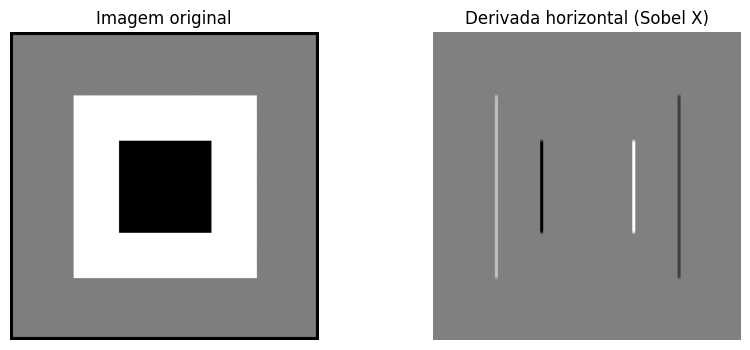

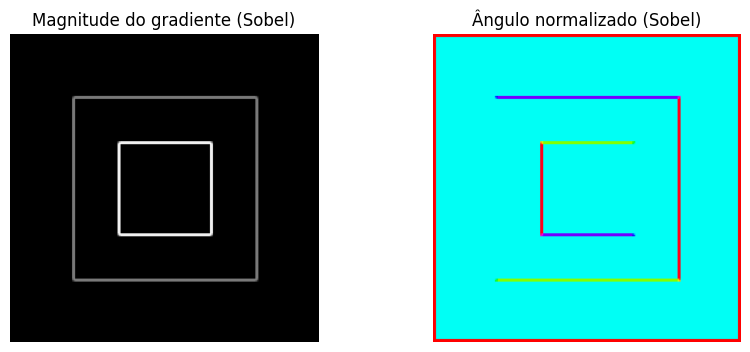

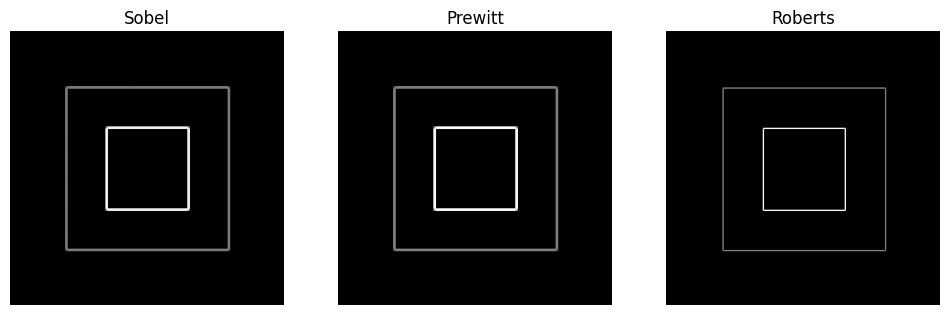

In [2]:
img_in = img_squares
img_test = img_in.astype(float)

sobel_x = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=float)
sobel_y = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=float)
prewitt_x = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]], dtype=float)
prewitt_y = np.array([[-1, -1, -1], [0, 0, 0], [1, 1, 1]], dtype=float)
roberts_x = np.array([[1, 0], [0, -1]], dtype=float)
roberts_y = np.array([[0, 1], [-1, 0]], dtype=float)

def convolve2d_manual(img, kernel):
    h, w = img.shape
    kh, kw = kernel.shape
    pad_h, pad_w = kh // 2, kw // 2
    padded = np.pad(img, ((pad_h, pad_h), (pad_w, pad_w)), mode='edge')
    output = np.zeros_like(img, dtype=float)
    for i in range(h):
        for j in range(w):
            region = padded[i:i + kh, j:j + kw]
            output[i, j] = (region * kernel).sum()
    return output

sobel_gx = convolve2d_manual(img_test, sobel_x)
sobel_gy = convolve2d_manual(img_test, sobel_y)

border = 2
img_b = np.pad(img_in, ((border, border), (border, border)), mode='constant', constant_values=0)
gx_b = np.pad(sobel_gx, ((border, border), (border, border)), mode='constant', constant_values=0)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img_b, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Imagem original')
axes[0].axis('off')
axes[1].imshow(gx_b, cmap='gray')
axes[1].set_title('Derivada horizontal (Sobel X)')
axes[1].axis('off')

sobel_mag = np.hypot(sobel_gx, sobel_gy)
sobel_angle = np.arctan2(sobel_gy, sobel_gx)
angle_norm = (sobel_angle + np.pi) / (2 * np.pi)

mag_b = np.pad(sobel_mag, ((border, border), (border, border)), mode='constant', constant_values=0)
ang_b = np.pad(angle_norm, ((border, border), (border, border)), mode='constant', constant_values=0)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(mag_b, cmap='gray')
axes[0].set_title('Magnitude do gradiente (Sobel)')
axes[0].axis('off')
axes[1].imshow(ang_b, cmap='hsv')
axes[1].set_title('Ângulo normalizado (Sobel)')
axes[1].axis('off')

prewitt_gx = convolve2d_manual(img_test, prewitt_x)
prewitt_gy = convolve2d_manual(img_test, prewitt_y)
prewitt_mag = np.hypot(prewitt_gx, prewitt_gy)

roberts_gx = convolve2d_manual(img_test, roberts_x)
roberts_gy = convolve2d_manual(img_test, roberts_y)
roberts_mag = np.hypot(roberts_gx, roberts_gy)

sobel_b = np.pad(sobel_mag, ((border, border), (border, border)), mode='constant', constant_values=0)
prewitt_b = np.pad(prewitt_mag, ((border, border), (border, border)), mode='constant', constant_values=0)
roberts_b = np.pad(roberts_mag, ((border, border), (border, border)), mode='constant', constant_values=0)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(sobel_b, cmap='gray')
axes[0].set_title('Sobel')
axes[0].axis('off')
axes[1].imshow(prewitt_b, cmap='gray')
axes[1].set_title('Prewitt')
axes[1].axis('off')
axes[2].imshow(roberts_b, cmap='gray')
axes[2].set_title('Roberts')
axes[2].axis('off')

plt.show()

## 4.2.3. Derivadas com Bibliotecas

Nesta célula retomam-se os conceitos de derivação espacial já apresentados, agora utilizando **implementações otimizadas** das bibliotecas **OpenCV** e **scikit-image**, e introduzindo o **operador Laplaciano** e o **filtro Scharr**. O objetivo é mostrar como esses métodos ampliam a análise de gradiente, explorando direções, magnitudes e variações de segunda ordem de forma mais precisa e eficiente.

**Descrição sequencial do código**  
1) Calculam-se as derivadas de Sobel com `cv2.Sobel`, equivalentes às obtidas manualmente anteriormente, mas executadas de forma vetorizada e com alta precisão. A magnitude e o ângulo do gradiente são obtidos e visualizados — tal como no exercício anterior — mas agora com a versão otimizada do OpenCV.  
2) Introduz-se o **operador Laplaciano** (`cv2.Laplacian`), que calcula a soma das segundas derivadas em $x$ e $y$. Diferente do Sobel, ele responde a mudanças de intensidade sem direção preferencial, sendo útil para detectar bordas finas ou pontos de inflexão da intensidade.  
3) Aplica-se o **filtro Scharr** (`filters.scharr`), uma variante aprimorada do Sobel que aumenta a precisão angular, minimizando distorções nas respostas diagonais. O resultado é comparado visualmente com o Sobel padrão, evidenciando sua suavidade e simetria.  

**Interpretação e observações**  
Os resultados confirmam que os operadores de primeira ordem (Sobel, Scharr) e de segunda ordem (Laplaciano) se complementam:
- O **Sobel (OpenCV)** mantém o mesmo comportamento descrito antes, mas com performance superior.  
- O **Laplaciano** revela detalhes adicionais e inversões de contraste, indicando bordas de segunda derivada.  
- O **Scharr** aprimora a continuidade e isotropia das bordas, sendo preferível em análises orientadas a gradiente precisas.

Para a fundamentação teórica e interpretação dos mapas de magnitude e ângulo, remete-se à célula anterior dedicada aos operadores Sobel, Prewitt e Roberts.

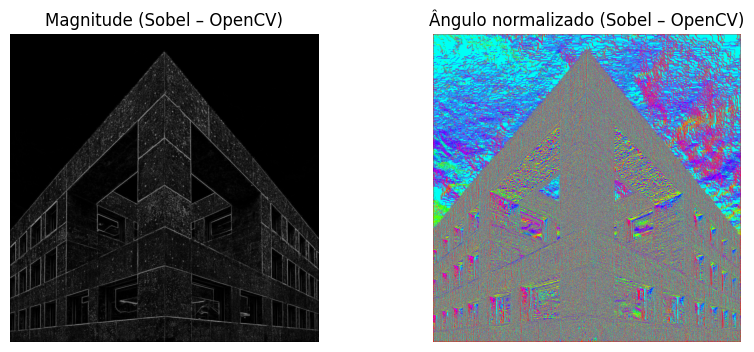

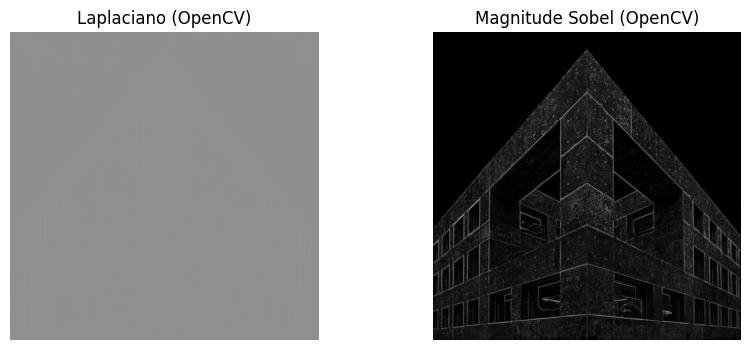

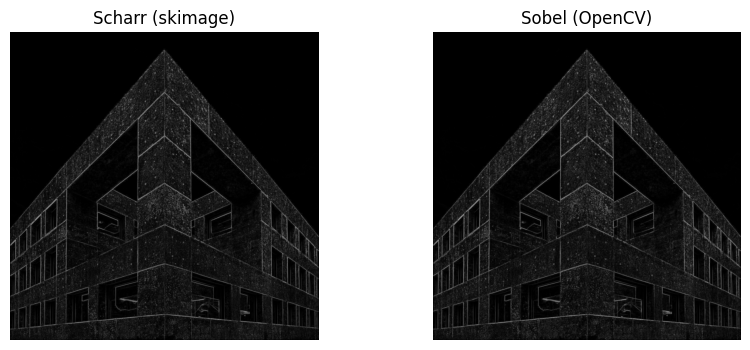

In [3]:
img_in = img_building
img_cv32 = img_in.astype(np.float32)

gx_cv = cv2.Sobel(img_cv32, cv2.CV_64F, 1, 0, ksize=3)
gy_cv = cv2.Sobel(img_cv32, cv2.CV_64F, 0, 1, ksize=3)
mag_cv = np.hypot(gx_cv, gy_cv)
angle_cv = np.arctan2(gy_cv, gx_cv)

border = 2
mag_b = np.pad(mag_cv, ((border, border), (border, border)), mode='constant', constant_values=0)
ang_b = np.pad((angle_cv + np.pi)/(2*np.pi), ((border, border), (border, border)), mode='constant', constant_values=0)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(mag_b, cmap='gray')
axes[0].set_title('Magnitude (Sobel – OpenCV)')
axes[0].axis('off')
axes[1].imshow(ang_b, cmap='hsv')
axes[1].set_title('Ângulo normalizado (Sobel – OpenCV)')
axes[1].axis('off')

lap_cv = cv2.Laplacian(img_cv32, cv2.CV_32F, ksize=3)
sobelx = cv2.Sobel(img_cv32, cv2.CV_32F, 1, 0, ksize=3)
sobely = cv2.Sobel(img_cv32, cv2.CV_32F, 0, 1, ksize=3)
mag_sobel = np.sqrt(sobelx**2 + sobely**2)

lap_b = np.pad(lap_cv, ((border, border), (border, border)), mode='constant', constant_values=0)
mag_sobel_b = np.pad(mag_sobel, ((border, border), (border, border)), mode='constant', constant_values=0)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(lap_b, cmap='gray')
axes[0].set_title('Laplaciano (OpenCV)')
axes[0].axis('off')
axes[1].imshow(mag_sobel_b, cmap='gray')
axes[1].set_title('Magnitude Sobel (OpenCV)')
axes[1].axis('off')

img_float = img_as_float(img_in)
scharr_img = filters.scharr(img_float)
scharr_b = np.pad(scharr_img, ((border, border), (border, border)), mode='constant', constant_values=0)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(scharr_b, cmap='gray')
axes[0].set_title('Scharr (skimage)')
axes[0].axis('off')
axes[1].imshow(mag_sobel_b, cmap='gray')
axes[1].set_title('Sobel (OpenCV)')
axes[1].axis('off')
plt.show()

## 4.2.4. Laplaciano

Esta célula introduz o **operador Laplaciano** e o conceito de **zero-crossings**, explorando também a sua versão suavizada — o **Laplacian of Gaussian (LoG)**. O foco é ilustrar como a segunda derivada da intensidade permite detetar bordas através das mudanças de sinal (positiva/negativa) no gradiente da imagem, e como a suavização prévia reduz o ruído sem perder as estruturas relevantes.

**Descrição sequencial do código**  
1) A imagem `img_coins` é convertida para `float` e aplicada a **máscara Laplaciana discreta**:
   $$
   \begin{bmatrix}
   0 & 1 & 0 \\
   1 & -4 & 1 \\
   0 & 1 & 0
   \end{bmatrix}
   $$
   que aproxima a soma das segundas derivadas $\frac{\partial^2 f}{\partial x^2} + \frac{\partial^2 f}{\partial y^2}$, realçando regiões onde a intensidade muda abruptamente.  
2) A convolução é realizada com `convolve2d_manual`, produzindo o mapa **Laplaciano** da imagem (`laplacian_manual`).  
3) A seguir, implementa-se a deteção de **zero-crossings** — os pontos onde o Laplaciano muda de sinal:
   - percorre-se a imagem com uma janela 3×3;  
   - se a região local contém valores positivos e negativos (`patch.min() < 0` e `patch.max() > 0`), o píxel central é marcado como 255 (borda).  
   O resultado é a imagem `zero_cross`, onde as transições de sinal são convertidas em contornos binários.  
4) Aplica-se uma suavização gaussiana (`gaussian_filter`, $\sigma = 1$) para reduzir ruído antes da derivação, originando o **Laplaciano após suavização** (`laplacian_smoothed`), ou seja, o **Laplacian of Gaussian (LoG)**.  
5) Repete-se o processo de deteção de zero-crossings na imagem suavizada, resultando em `zero_cross_smoothed`.  
6) As figuras exibem:
   - Comparação entre Laplaciano original e suavizado (redução de ruído e bordas mais suaves);  
   - Comparação entre zero-crossings diretos e com suavização, evidenciando o efeito da filtragem prévia.  

**Interpretação e observações**  
O **Laplaciano** é um operador de segunda derivada, e por isso responde fortemente a pequenas variações locais — o que o torna sensível ao ruído. O **zero-crossing** indica uma inflexão na intensidade luminosa, correspondendo à localização aproximada das bordas.  
A suavização Gaussiana atenua essas variações espúrias, resultando num contorno mais limpo e contínuo:  
- o **Laplaciano simples** tende a gerar contornos fragmentados;  
- o **LoG** produz fronteiras mais estáveis e menos sensíveis a textura ou ruído.  

Este processo constitui a base do detetor de **Marr–Hildreth**, que combina derivação e filtragem gaussiana para localizar bordas a partir das mudanças de sinal do Laplaciano.  
A experiência mostra a importância da sequência **suavizar → derivar → detetar zero-crossing**, que se tornou um padrão nas abordagens de deteção de bordas multiescala.

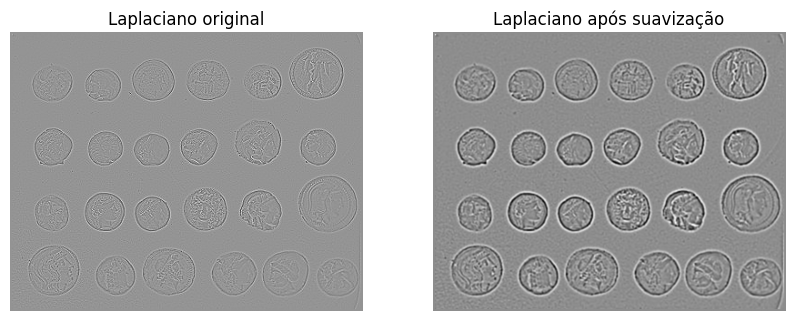

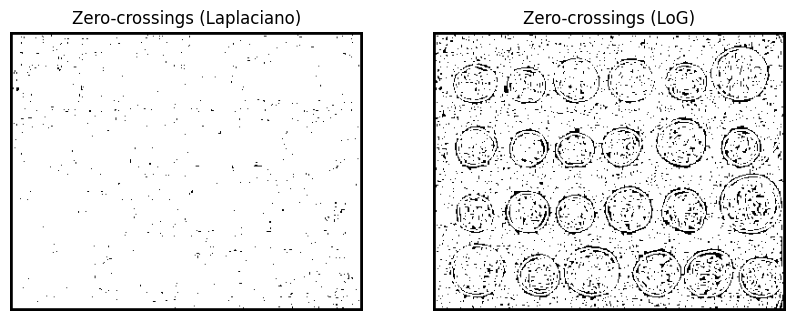

In [4]:
img_in = img_coins
img_gray = img_in.astype(float)

laplacian_mask = np.array([[0, 1, 0], [1, -4, 1], [0, 1, 0]], dtype=float)
laplacian_manual = convolve2d_manual(img_gray, laplacian_mask)

border = 2
lap_b = np.pad(laplacian_manual, ((border, border), (border, border)), mode='constant', constant_values=0)

rows, cols = laplacian_manual.shape
zero_cross = np.zeros_like(laplacian_manual, dtype=np.uint8)
for i in range(1, rows - 1):
    for j in range(1, cols - 1):
        patch = laplacian_manual[i - 1:i + 2, j - 1:j + 2]
        if patch.min() < 0 and patch.max() > 0:
            zero_cross[i, j] = 255

zero_cross_b = np.pad(zero_cross, ((border, border), (border, border)), mode='constant', constant_values=0)
img_smoothed = gaussian_filter(img_gray, sigma=1)
laplacian_smoothed = convolve2d_manual(img_smoothed, laplacian_mask)

lap_smooth_b = np.pad(laplacian_smoothed, ((border, border), (border, border)), mode='constant', constant_values=0)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(lap_b, cmap='gray')
axes[0].set_title('Laplaciano original')
axes[0].axis('off')
axes[1].imshow(lap_smooth_b, cmap='gray')
axes[1].set_title('Laplaciano após suavização')
axes[1].axis('off')

rows2, cols2 = laplacian_smoothed.shape
zero_cross_smoothed = np.zeros_like(laplacian_smoothed, dtype=np.uint8)
for i in range(1, rows2 - 1):
    for j in range(1, cols2 - 1):
        patch = laplacian_smoothed[i - 1:i + 2, j - 1:j + 2]
        if patch.min() < 0 and patch.max() > 0:
            zero_cross_smoothed[i, j] = 255

zc1_b = np.pad(zero_cross, ((border, border), (border, border)), mode='constant', constant_values=0)
zc2_b = np.pad(zero_cross_smoothed, ((border, border), (border, border)), mode='constant', constant_values=0)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(zc1_b, cmap='gray')
axes[0].set_title('Zero-crossings (Laplaciano)')
axes[0].axis('off')
axes[1].imshow(zc2_b, cmap='gray')
axes[1].set_title('Zero-crossings (LoG)')
axes[1].axis('off')
plt.show()

## 4.2.5. Filtros e Derivadas de Ordem Superior

Esta célula aprofunda o estudo do **Laplacian of Gaussian (LoG)**, mostrando como o filtro é construído explicitamente a partir da composição entre a **suavização Gaussiana** e a **derivação Laplaciana**, e comparando a sua implementação manual com a versão otimizada da biblioteca `scikit-image`. O objetivo é compreender a estrutura matemática do kernel LoG e como este atua na filtragem de imagens reais.

**Descrição sequencial do código**  
1) Define-se a função `gaussian_2d(size, sigma)` que gera uma máscara 2D Gaussiana:
   $$
   G(x, y) = \frac{1}{2\pi\sigma^2} e^{-\frac{x^2 + y^2}{2\sigma^2}}
   $$
   normalizada de modo que a soma de todos os elementos seja 1.  
   Esta máscara realiza a **suavização isotrópica** da imagem, reduzindo o ruído e as variações locais.  
2) Define-se a função `log_kernel(size, sigma)` que implementa a **segunda derivada** da Gaussiana:
   $$
   \text{LoG}(x, y) = \frac{x^2 + y^2 - 2\sigma^2}{\sigma^4} \, e^{-\frac{x^2 + y^2}{2\sigma^2}}
   $$
   Após o cálculo, a média do kernel é subtraída para garantir centragem em torno de zero — essencial para a deteção de transições positivas e negativas na intensidade.  
3) São criadas duas máscaras 7×7 (σ = 1.0):
   - a **máscara Gaussiana**, exibida em tons quentes (`inferno`), e  
   - a **máscara LoG**, exibida com colormap divergente (`seismic`), destacando as zonas positivas (vermelho) e negativas (azul) em torno da origem.  
4) Aplica-se o kernel LoG à imagem original com `convolve2d_manual`, obtendo uma versão filtrada (`log_filtered`) que realça as bordas através das zonas de transição.  
5) Em paralelo, reproduz-se o mesmo processo com `scikit-image`:  
   - suavização via `filters.gaussian`,  
   - derivação via `filters.laplace`,  
   resultando no mesmo efeito do **LoG composto**.  
6) Por fim, são comparados lado a lado os resultados das duas abordagens — **manual** e **biblioteca** — demonstrando que a equivalência entre $(\nabla^2 G) * I$ e $\nabla^2(G * I)$ é preservada numericamente.

**Interpretação e observações**  
O filtro **Laplacian of Gaussian** combina os benefícios da suavização e da derivação:
- a parte **Gaussiana** controla a escala de observação (quanto maior σ, mais grossas as bordas detetadas);  
- a parte **Laplaciana** identifica as regiões de variação máxima da intensidade, correspondendo às bordas e contornos.  

Visualmente, o kernel LoG apresenta uma forma característica de **“chapéu mexicano”** (*Mexican hat*), com um centro negativo cercado por valores positivos — uma estrutura radial que atua como detector de contrastes locais.  

O resultado do LoG suaviza as pequenas flutuações e enfatiza apenas transições estruturais, tornando-se a base de muitos detetores clássicos de bordas e pontos de interesse (como Marr–Hildreth e DoG em SIFT).  
Esta célula, portanto, mostra de forma explícita como a matemática do filtro se traduz num comportamento espacial controlável pela escala σ.

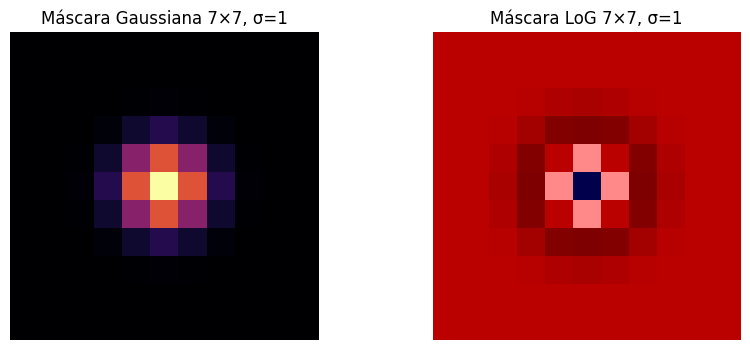

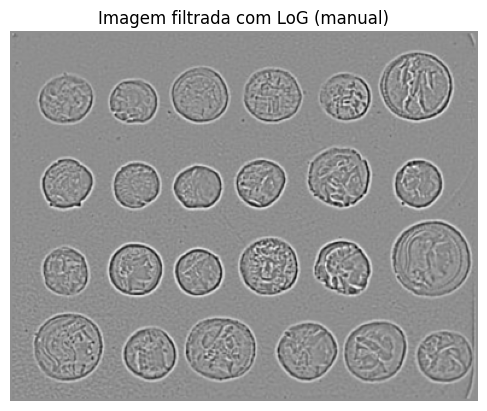

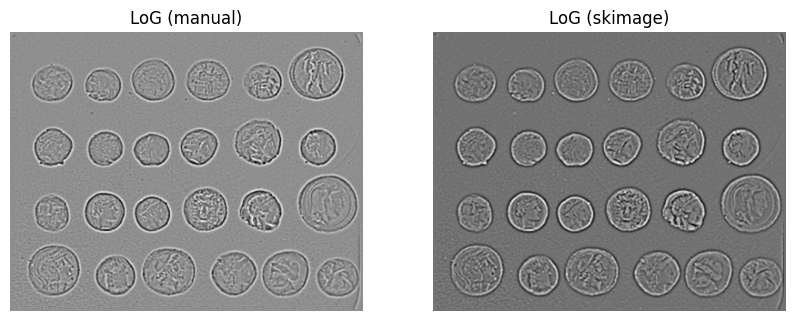

In [5]:
img_in = img_coins
img_gray = img_in.astype(float)

def gaussian_2d(size, sigma):
    ax = np.arange(-(size // 2), size // 2 + 1)
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx ** 2 + yy ** 2) / (2 * sigma ** 2))
    return kernel / kernel.sum()

def log_kernel(size, sigma):
    ax = np.arange(-(size // 2), size // 2 + 1)
    xx, yy = np.meshgrid(ax, ax)
    norm = (xx ** 2 + yy ** 2 - 2 * sigma ** 2) / (sigma ** 4)
    kernel = norm * np.exp(-(xx ** 2 + yy ** 2) / (2 * sigma ** 2))
    kernel = kernel - kernel.mean()
    return kernel

gauss_kernel = gaussian_2d(7, 1.0)
log_mask = log_kernel(7, 1.0)

border = 2
gauss_b = np.pad(gauss_kernel, ((border, border), (border, border)), mode='constant', constant_values=0)
log_b = np.pad(log_mask, ((border, border), (border, border)), mode='constant', constant_values=0)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(gauss_b, cmap='inferno')
axes[0].set_title('Máscara Gaussiana 7×7, σ=1')
axes[0].axis('off')
axes[1].imshow(log_b, cmap='seismic')
axes[1].set_title('Máscara LoG 7×7, σ=1')
axes[1].axis('off')

log_filtered = convolve2d_manual(img_gray, log_mask)
log_filtered_b = np.pad(log_filtered, ((border, border), (border, border)), mode='constant', constant_values=0)

fig, ax = plt.subplots()
ax.imshow(log_filtered_b, cmap='gray')
ax.set_title('Imagem filtrada com LoG (manual)')
ax.axis('off')

gauss_sk = filters.gaussian(img_gray, sigma=1.0)
lap_sk = filters.laplace(gauss_sk)
lap_sk_b = np.pad(lap_sk, ((border, border), (border, border)), mode='constant', constant_values=0)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(log_filtered_b, cmap='gray')
axes[0].set_title('LoG (manual)')
axes[0].axis('off')
axes[1].imshow(lap_sk_b, cmap='gray')
axes[1].set_title('LoG (skimage)')
axes[1].axis('off')
plt.show()

## 4.2.6. Algoritmo de Canny

Esta célula implementa passo a passo o **algoritmo de Canny**, um dos métodos mais completos e robustos de **detecção de arestas**. O processo é decomposto nas suas quatro etapas fundamentais — suavização, cálculo de gradiente, supressão não-máxima e histerese — permitindo visualizar a contribuição de cada fase no resultado final.

**Descrição sequencial do código**  
1) A imagem `img_lines` é convertida para `float` e suavizada com um **filtro Gaussiano** (`gaussian_filter`, σ=1.4) para reduzir ruído e pequenas flutuações que poderiam gerar bordas falsas.  
2) Calculam-se as derivadas com **máscaras de Sobel** (`sobel_x`, `sobel_y`) aplicadas por convolução manual (`convolve2d_manual`).  
   - As derivadas horizontais e verticais produzem o campo de gradiente;  
   - A **magnitude** ($G = \sqrt{G_x^2 + G_y^2}$) indica a intensidade das bordas;  
   - O **ângulo** ($\theta = \arctan(G_y / G_x)$) define a direção da variação.  
3) Executa-se a **supressão não-máxima (NMS)**, que afina as bordas, mantendo apenas os píxeis que são máximos locais ao longo da direção do gradiente:  
   - o ângulo é quantizado em quatro direções principais (0°, 45°, 90°, 135°);  
   - compara-se cada píxel com os dois vizinhos nessa direção;  
   - o píxel é preservado se tiver magnitude superior ou igual a ambos.  
4) Aplica-se a **dupla limiarização** com valores normalizados `T_high = 0.2` e `T_low = 0.1`:  
   - píxeis acima de `T_high` são classificados como **bordas fortes**;  
   - píxeis entre `T_low` e `T_high` são **bordas fracas**;  
   - os restantes são descartados.  
5) Realiza-se a etapa de **histerese**, que garante continuidade das bordas:
   - cada borda forte propaga-se recursivamente para píxeis vizinhos classificados como fracos, convertendo-os também em bordas;  
   - apenas as cadeias de bordas conectadas a regiões fortes são mantidas no resultado final (`edges_final`).  
6) As imagens intermédias são visualizadas organizadas por fase:
   - (1,1) Imagem original  
   - (1,2) Suavização Gaussiana  
   - (2,1) Magnitude do gradiente  
   - (2,2) Supressão não-máxima  
   - (3,1) Composição intermédia (mag + nms)  
   - (3,2) Resultado final após histerese.  

**Interpretação e observações**  
O algoritmo de **Canny** (1986) é considerado o modelo clássico de deteção de bordas por satisfazer três critérios ideais:
1. **Boa deteção** — maximiza a taxa de verdadeiros positivos (bordas reais).  
2. **Boa localização** — as bordas detetadas estão o mais próximo possível das reais.  
3. **Resposta única** — minimiza múltiplas deteções para a mesma borda.  

O pipeline integra suavização, gradiente, afinação e decisão binária — garantindo alta precisão mesmo em imagens com ruído.  
A etapa de **histerese** é o diferencial essencial, pois liga bordas fracas relevantes a bordas fortes próximas, assegurando continuidade topológica.  

Em resumo:
- A suavização controla o ruído e define a escala de análise.  
- O gradiente de Sobel fornece direção e intensidade.  
- A supressão não-máxima refina o contorno.  
- A histerese seleciona as bordas conectadas mais consistentes.  

O resultado é uma representação binária de arestas finas, contínuas e bem localizadas, que servem de base para inúmeras aplicações subsequentes de **segmentação**, **reconhecimento de objetos** e **extração de formas geométricas**.

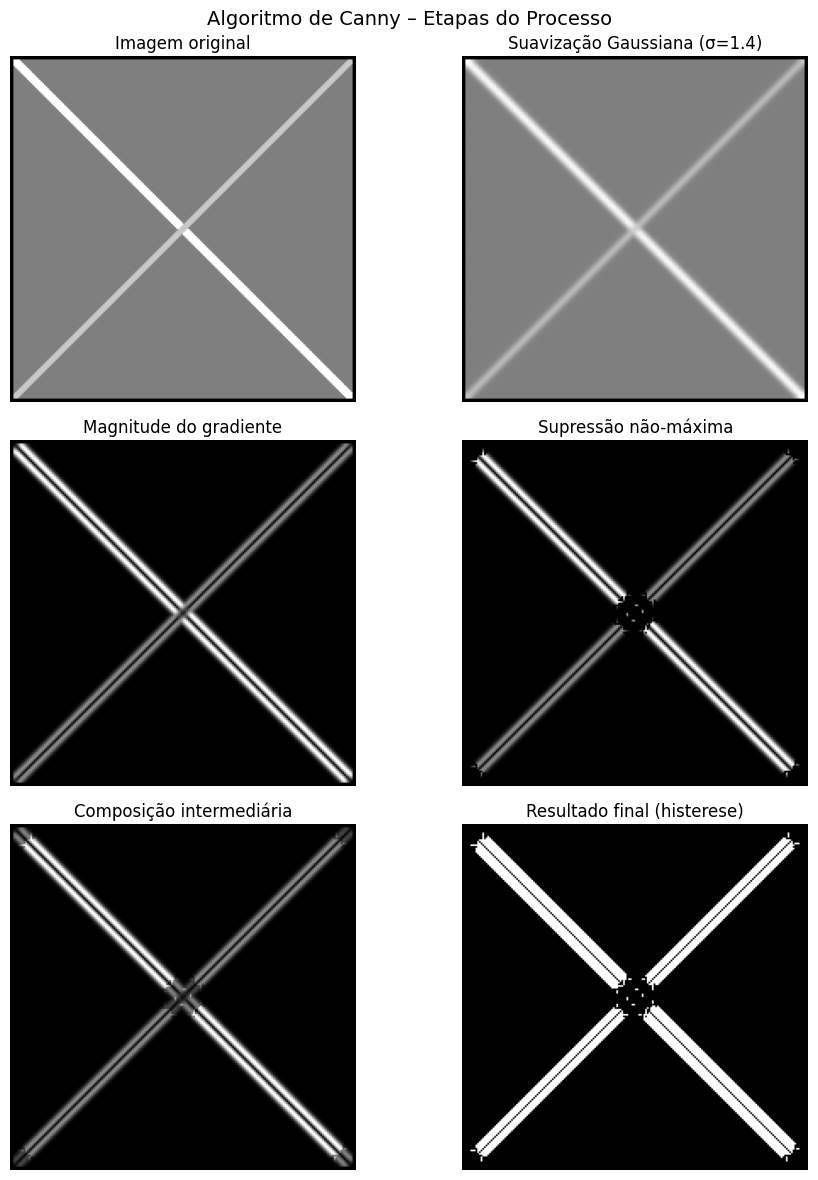

In [6]:
img_in = img_lines  
canny_img = img_in.astype(float)
canny_blur = gaussian_filter(canny_img, sigma=1.4)

sobel_x = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=float)
sobel_y = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=float)

gx_canny = convolve2d_manual(canny_blur, sobel_x)
gy_canny = convolve2d_manual(canny_blur, sobel_y)
mag_canny = np.hypot(gx_canny, gy_canny)
angle_canny = np.arctan2(gy_canny, gx_canny)
mag_norm = mag_canny / (mag_canny.max() + 1e-8)

h, w = mag_norm.shape
nms = np.zeros_like(mag_norm)
angle_deg = (np.rad2deg(angle_canny) + 180) % 180
for i in range(1, h - 1):
    for j in range(1, w - 1):
        q, r = 0, 0
        ang = angle_deg[i, j]
        if (0 <= ang < 22.5) or (157.5 <= ang < 180):
            q, r = mag_norm[i, j + 1], mag_norm[i, j - 1]
        elif (22.5 <= ang < 67.5):
            q, r = mag_norm[i + 1, j - 1], mag_norm[i - 1, j + 1]
        elif (67.5 <= ang < 112.5):
            q, r = mag_norm[i + 1, j], mag_norm[i - 1, j]
        else:
            q, r = mag_norm[i - 1, j - 1], mag_norm[i + 1, j + 1]
        if mag_norm[i, j] >= q and mag_norm[i, j] >= r:
            nms[i, j] = mag_norm[i, j]

T_high = 0.2
T_low = 0.1
strong = (nms >= T_high).astype(np.uint8)
weak = ((nms >= T_low) & (nms < T_high)).astype(np.uint8)
edges_final = np.zeros_like(nms, dtype=np.uint8)

h_f, w_f = nms.shape
for i in range(h_f):
    for j in range(w_f):
        if strong[i, j]:
            edges_final[i, j] = 255
            stack = [(i, j)]
            while stack:
                x, y = stack.pop()
                for dx in [-1, 0, 1]:
                    for dy in [-1, 0, 1]:
                        nx, ny = x + dx, y + dy
                        if 0 <= nx < h_f and 0 <= ny < w_f and edges_final[nx, ny] == 0:
                            if strong[nx, ny] or weak[nx, ny]:
                                edges_final[nx, ny] = 255
                                stack.append((nx, ny))

border = 2
img_b = np.pad(img_in, ((border, border), (border, border)), mode='constant', constant_values=0)
blur_b = np.pad(canny_blur, ((border, border), (border, border)), mode='constant', constant_values=0)
mag_b = np.pad(mag_norm, ((border, border), (border, border)), mode='constant', constant_values=0)
nms_b = np.pad(nms, ((border, border), (border, border)), mode='constant', constant_values=0)
edges_b = np.pad(edges_final, ((border, border), (border, border)), mode='constant', constant_values=0)

fig, axes = plt.subplots(3, 2, figsize=(10, 12))

axes[0, 0].imshow(img_b, cmap='gray', vmin=0, vmax=255)
axes[0, 0].set_title('Imagem original')
axes[0, 0].axis('off')

axes[0, 1].imshow(blur_b, cmap='gray')
axes[0, 1].set_title('Suavização Gaussiana (σ=1.4)')
axes[0, 1].axis('off')

axes[1, 0].imshow(mag_b, cmap='gray')
axes[1, 0].set_title('Magnitude do gradiente')
axes[1, 0].axis('off')

axes[1, 1].imshow(nms_b, cmap='gray')
axes[1, 1].set_title('Supressão não-máxima')
axes[1, 1].axis('off')

axes[2, 0].imshow((mag_b + nms_b) / 2, cmap='gray')
axes[2, 0].set_title('Composição intermediária')
axes[2, 0].axis('off')

axes[2, 1].imshow(edges_b, cmap='gray')
axes[2, 1].set_title('Resultado final (histerese)')
axes[2, 1].axis('off')

fig.suptitle('Algoritmo de Canny – Etapas do Processo', fontsize=14)
plt.tight_layout()
plt.show()

## 4.2.7. Canny com OpenCV

Esta célula complementa a anterior, comparando o **Canny manual** implementado passo a passo com a versão altamente otimizada do **OpenCV (`cv2.Canny`)** e explorando o impacto dos principais parâmetros do algoritmo — o desvio padrão da suavização ($\sigma$) e os limiares inferior/superior da histerese.

**Descrição sequencial do código**  
1) A imagem e o resultado manual (`edges_final`) são acolchoados apenas para visualização uniforme.  
2) O **Canny do OpenCV** é executado com os parâmetros padrão `(100, 200)`, representando os limiares inferior e superior da etapa de histerese.  
   - O resultado é colocado lado a lado com o Canny manual e a imagem original, permitindo verificar a equivalência qualitativa das bordas obtidas.  
3) Na segunda parte, realiza-se uma **exploração paramétrica** do comportamento do `cv2.Canny`:  
   - variando o nível de suavização gaussiana $\sigma \in \{0.5, 1.0, 2.0\}$;  
   - e os pares de limiares $(t_{low}, t_{high}) \in \{(50,100), (100,200), (150,300)\}$.  
   Cada combinação gera um painel (3×3) mostrando como o detector reage a diferentes escalas e sensibilidades.

**Interpretação e observações**  
Esta comparação confirma a consistência entre a implementação manual e a de biblioteca, evidenciando que o **núcleo conceitual do algoritmo** é o mesmo.  
O estudo paramétrico revela que:
- **Valores baixos de $\sigma$** preservam detalhes finos, mas aumentam o ruído; valores altos produzem bordas mais contínuas e simplificadas.  
- **Limiar inferior (tₗ)** controla a sensibilidade inicial — quanto menor, mais bordas fracas são consideradas;  
- **Limiar superior (tₕ)** define o rigor na seleção final — quanto maior, menos bordas sobrevivem.  
A escolha ideal depende do conteúdo e do ruído da imagem: imagens com contornos suaves beneficiam de σ maior e limiares mais altos, enquanto imagens com detalhes finos exigem menor suavização e limiares mais baixos.

Esta célula encerra o ciclo da **deteção de arestas por Canny**, mostrando como teoria, implementação manual e ferramenta prática convergem para um mesmo princípio: extrair **bordas finas, contínuas e hierarquicamente controláveis** a partir de gradientes multietapa.

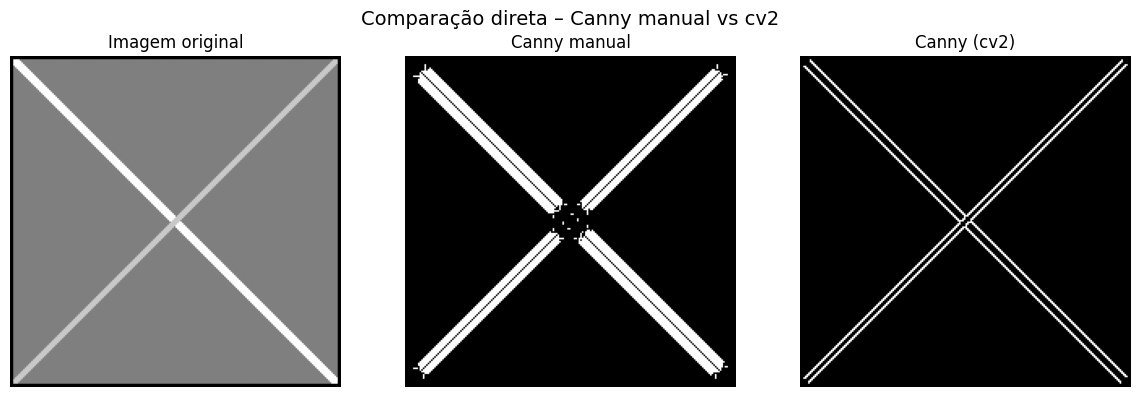

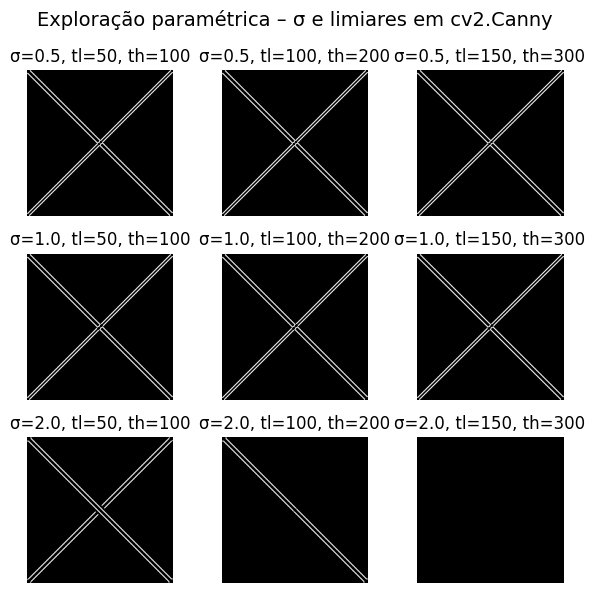

In [7]:
img_in = img_lines  
img_cv = img_in.astype(np.uint8)

border = 2
img_b = np.pad(img_in, ((border, border), (border, border)), mode='constant', constant_values=0)
manual_b = np.pad(edges_final, ((border, border), (border, border)), mode='constant', constant_values=0)

canny_cv = cv2.Canny(img_cv, 100, 200)
canny_cv_b = np.pad(canny_cv, ((border, border), (border, border)), mode='constant', constant_values=0)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(img_b, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Imagem original')
axes[0].axis('off')
axes[1].imshow(manual_b, cmap='gray')
axes[1].set_title('Canny manual')
axes[1].axis('off')
axes[2].imshow(canny_cv_b, cmap='gray')
axes[2].set_title('Canny (cv2)')
axes[2].axis('off')
fig.suptitle('Comparação direta – Canny manual vs cv2', fontsize=14)
plt.tight_layout()
plt.show()

sigma_vals = [0.5, 1.0, 2.0]
th_pairs = [(50, 100), (100, 200), (150, 300)]

fig, axes = plt.subplots(3, 3, figsize=(6, 6))
for i, s in enumerate(sigma_vals):
    blurred = gaussian_filter(img_in.astype(float), sigma=s)
    for j, (tl, th) in enumerate(th_pairs):
        edges_var = cv2.Canny(blurred.astype(np.uint8), tl, th)
        axes[i, j].imshow(edges_var, cmap='gray', vmin=0, vmax=255)
        axes[i, j].set_title(f'σ={s}, tl={tl}, th={th}')
        axes[i, j].axis('off')
fig.suptitle('Exploração paramétrica – σ e limiares em cv2.Canny', fontsize=14)
plt.tight_layout()
plt.show()

## 4.2.8. Edge Linking

Esta célula apresenta a etapa complementar de **ligação e reforço de arestas (edge linking)**, uma pós-processamento simples, mas eficaz, que aumenta a continuidade dos contornos após a detecção inicial (neste caso, o Canny manual). O objetivo é reduzir fragmentações e melhorar a coerência estrutural das bordas, particularmente em imagens técnicas ou sintéticas.

**Descrição sequencial do código**  
1) Define-se a função `link_edges(img_edges)`, que aplica uma **dilatação seguida de erosão** (operação morfológica conhecida como *closing*).  
   - A **dilatação** expande levemente as arestas, fazendo com que pequenas lacunas entre segmentos próximos se fechem.  
   - A **erosão** subsequente restaura a espessura original das linhas, mantendo a conectividade recém-criada.  
   - O kernel 3×3 usado é cruzado (não diagonal), reforçando conexões ortogonais.  
2) O resultado é a imagem `linked_edges`, onde as arestas interrompidas são suavemente unidas.  
3) Para medir o efeito quantitativo, define-se `average_edge_length(edge_map)`, que:
   - utiliza `cv2.connectedComponents` para identificar componentes conexos,  
   - calcula o comprimento (número de píxeis) de cada segmento,  
   - retorna a média desses comprimentos.  
4) Calculam-se as médias antes e depois da ligação (`avg_len_before`, `avg_len_after`), permitindo uma comparação direta do efeito.  
5) Cria-se um **mapa de diferenças colorido** (`diff_map`), onde os píxeis que surgiram após a ligação (novas conexões) são mostrados a vermelho.  
6) A figura 2×2 exibe:
   - imagem original,  
   - arestas iniciais do Canny manual,  
   - resultado após *edge linking*,  
   - e o mapa de diferenças destacando as ligações adicionadas.  
7) Finalmente, um gráfico de barras resume o **comprimento médio das arestas antes e depois**, demonstrando quantitativamente o ganho de continuidade.

**Interpretação e observações**  
O *edge linking* melhora a **coerência geométrica** das bordas, reduzindo fragmentações causadas por ruído, variação de contraste ou limiares muito restritivos.  
- O aumento do comprimento médio confirma a **fusão de segmentos** previamente isolados.  
- O mapa de diferenças (em vermelho) ajuda a visualizar as **novas conexões criadas** sem alterar significativamente a estrutura geral da imagem.  

Embora este exemplo use uma abordagem morfológica simples, técnicas mais avançadas de ligação podem recorrer a:
- **análise direcional** (seguimento de orientação de gradiente),  
- **algoritmos de rastreio de contornos** (edge tracing), ou  
- **modelos baseados em grafos** (ligação probabilística).  

Em suma, esta etapa refina o resultado da detecção de arestas, tornando os contornos **mais contínuos, interpretáveis e adequados para análises subsequentes** — como vetorização, segmentação de regiões ou extração de formas estruturadas.

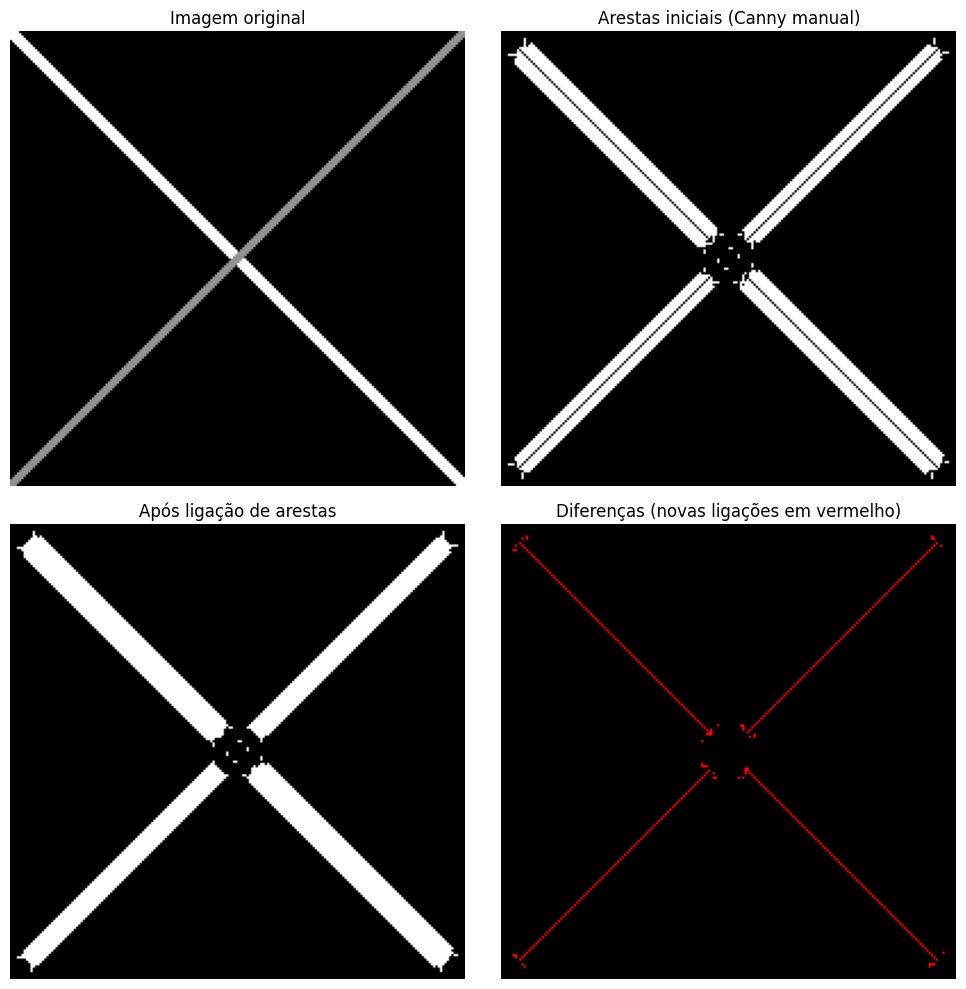

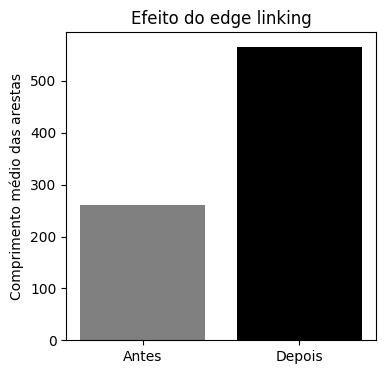

In [8]:
img_in = img_lines

def link_edges(img_edges):
    kernel = np.array([[0, 1, 0], [1, 1, 1], [0, 1, 0]], dtype=np.uint8)
    dil = cv2.dilate(img_edges, kernel, iterations=1)
    linked = cv2.erode(dil, kernel, iterations=1)
    return linked

linked_edges = link_edges(edges_final)

def average_edge_length(edge_map):
    num_labels, labels = cv2.connectedComponents(edge_map)
    lengths = [np.sum(labels == i) for i in range(1, num_labels)]
    return np.mean(lengths) if lengths else 0

avg_len_before = average_edge_length((edges_final > 0).astype(np.uint8))
avg_len_after = average_edge_length((linked_edges > 0).astype(np.uint8))

diff_map = np.zeros((*img_in.shape, 3), dtype=np.uint8)
diff_map[(linked_edges > 0) & (edges_final == 0)] = [255, 0, 0]

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes[0, 0].imshow(img_in, cmap='gray')
axes[0, 0].set_title('Imagem original')
axes[0, 0].axis('off')

axes[0, 1].imshow(edges_final, cmap='gray')
axes[0, 1].set_title('Arestas iniciais (Canny manual)')
axes[0, 1].axis('off')

axes[1, 0].imshow(linked_edges, cmap='gray')
axes[1, 0].set_title('Após ligação de arestas')
axes[1, 0].axis('off')

axes[1, 1].imshow(diff_map)
axes[1, 1].set_title('Diferenças (novas ligações em vermelho)')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(4, 4))
ax.bar(['Antes', 'Depois'], [avg_len_before, avg_len_after], color=['gray', 'black'])
ax.set_ylabel('Comprimento médio das arestas')
ax.set_title('Efeito do edge linking')
plt.show()

## 4.2.9. Transformada de Hough (Linhas)

Esta célula introduz a **Transformada de Hough para detecção de linhas**, comparando a sua implementação manual com as funções equivalentes do OpenCV (`cv2.HoughLines` e `cv2.HoughLinesP`). O objetivo é demonstrar o funcionamento do **espaço de parâmetros ρ–θ**, onde cada ponto da imagem de arestas gera uma família de linhas possíveis, e as linhas reais surgem como **picos no acumulador**.

**Descrição sequencial do código**  
1) A função `synthesize_hough_lines` gera uma **imagem sintética** com várias linhas inclinadas e ruído gaussiano controlado (`noise_sigma`). Esta imagem facilita a visualização do espaço ρ–θ e a validação dos resultados.  
2) As arestas são extraídas com o detector de **Canny**, produzindo uma versão binária da imagem (`edges_hough`).  
3) Define-se `hough_lines_accumulator`, que implementa a **Transformada de Hough** manualmente:
   - Cada píxel de aresta $(x, y)$ é projetado em todas as direções θ de –90° a +90°;  
   - Para cada θ, calcula-se $\rho = x \cos(\theta) + y \sin(\theta)$;  
   - O acumulador é incrementado na célula correspondente $(\rho, \theta)$;  
   - O resultado é uma matriz onde picos indicam possíveis linhas.  
4) A função `extract_lines_from_hough` localiza os **picos mais intensos** do acumulador (acima de um limiar), converte os parâmetros (ρ, θ) em coordenadas cartesianas e traça as linhas correspondentes sobre a imagem original.  
5) O acumulador é normalizado e exibido com colormap `plasma`, e os picos detetados são assinalados a branco.  
6) Em seguida, são executadas as duas funções equivalentes do OpenCV:
   - `cv2.HoughLines`: deteta linhas infinitas (representação clássica em ρ–θ);  
   - `cv2.HoughLinesP`: deteta segmentos finitos usando parâmetros adicionais `minLineLength` e `maxLineGap`.  
7) São geradas seis subfiguras:
   - (1,1) Imagem sintética;  
   - (1,2) Arestas por Canny;  
   - (1,3) Acumulador de Hough com picos;  
   - (2,1) Linhas extraídas manualmente;  
   - (2,2) Linhas detetadas por `cv2.HoughLines`;  
   - (2,3) Segmentos obtidos por `cv2.HoughLinesP`.

**Interpretação e observações**  
A **Transformada de Hough** converte o problema de detecção de linhas no espaço da imagem para um **problema de picos em um espaço de parâmetros**.  
- Cada píxel de aresta contribui com uma **curva sinusoidal** no espaço ρ–θ;  
- Onde várias sinusoides se cruzam, há consenso entre diferentes píxeis — isto identifica uma linha real.  

O acumulador é, portanto, um histograma bidimensional de evidências.  
- Picos bem definidos correspondem a linhas fortes e bem alinhadas;  
- Regiões difusas indicam ruído ou múltiplas orientações próximas.  

As versões do OpenCV otimizam este processo, e `HoughLinesP` adiciona a detecção de **segmentos finitos**, tornando-o mais prático para análise de objetos e vetorização.  

Em síntese:
- A implementação manual explicita a **geometria do espaço ρ–θ**;  
- O acumulador fornece uma visão intuitiva de como linhas emergem de interseções de sinusoides;  
- As funções do OpenCV oferecem **eficiência e robustez**, mas seguem exatamente o mesmo princípio matemático.  

Esta demonstração evidencia a **ponte entre teoria e prática** — da representação geométrica contínua até a deteção automática de estruturas lineares em imagens reais.

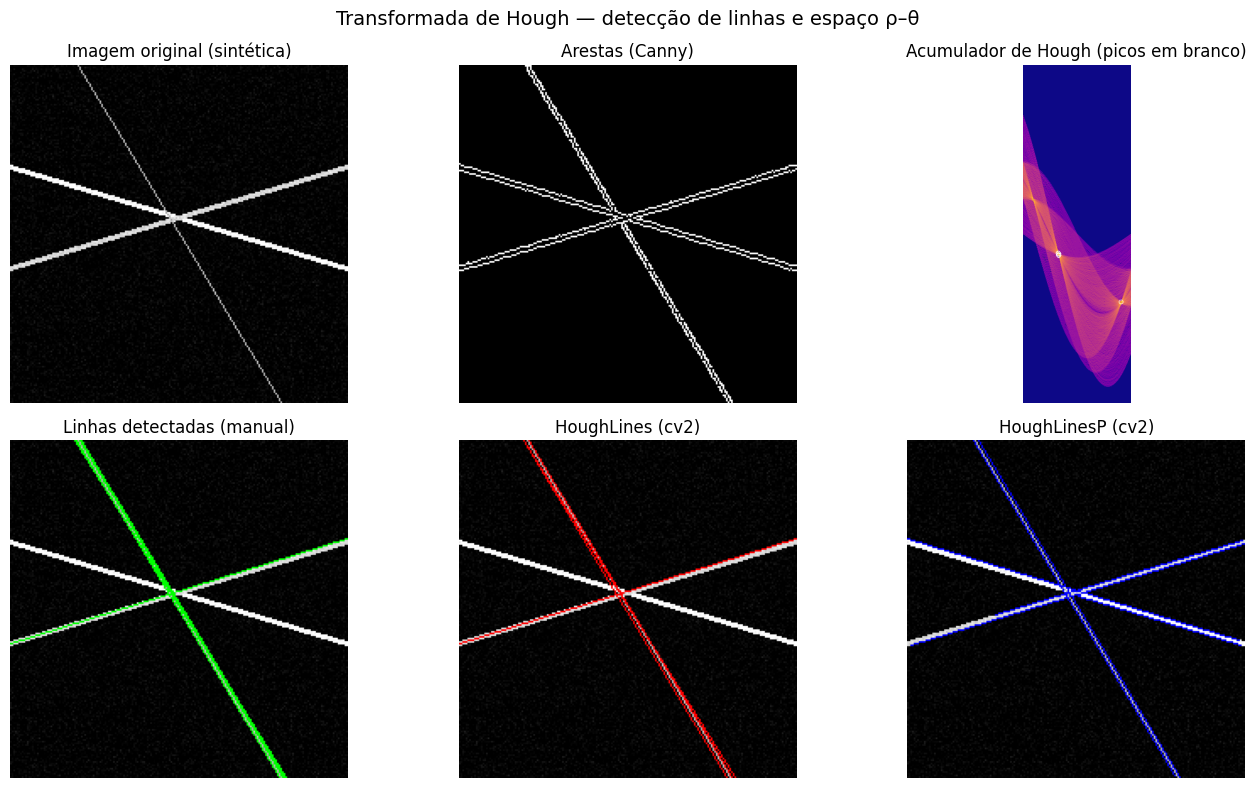

In [9]:
def synthesize_hough_lines(size=200, noise_sigma=10):
    img = np.zeros((size, size), dtype=np.uint8)
    cv2.line(img, (0, int(size * 0.3)), (size - 1, int(size * 0.6)), 255, 2)
    cv2.line(img, (0, int(size * 0.6)), (size - 1, int(size * 0.3)), 220, 2)
    cv2.line(img, (int(size * 0.2), 0), (int(size * 0.8), size - 1), 180, 1)
    noise = np.random.normal(0, noise_sigma, (size, size))
    noisy = np.clip(img.astype(np.float32) + noise, 0, 255).astype(np.uint8)
    return noisy

def hough_lines_accumulator(edge_img):
    h, w = edge_img.shape
    diag_len = int(np.ceil(np.hypot(h, w)))
    rhos = np.linspace(-diag_len, diag_len, 2 * diag_len + 1)
    thetas = np.deg2rad(np.arange(-90, 90))
    accumulator = np.zeros((len(rhos), len(thetas)), dtype=np.uint64)
    y_idxs, x_idxs = np.nonzero(edge_img)
    for i in range(len(x_idxs)):
        x, y = x_idxs[i], y_idxs[i]
        for t_idx, theta in enumerate(thetas):
            rho = int(np.round(x * np.cos(theta) + y * np.sin(theta)))
            accumulator[rho + diag_len, t_idx] += 1
    return accumulator, rhos, thetas

def extract_lines_from_hough(acc, rhos, thetas, threshold=120, max_lines=5):
    peaks = np.argwhere(acc > threshold)
    peaks = peaks[np.argsort(-acc[peaks[:, 0], peaks[:, 1]])[:max_lines]]
    lines = []
    for rho_idx, theta_idx in peaks:
        rho, theta = rhos[rho_idx], thetas[theta_idx]
        a, b = np.cos(theta), np.sin(theta)
        x0, y0 = a * rho, b * rho
        x1, y1 = int(x0 + 1000 * (-b)), int(y0 + 1000 * (a))
        x2, y2 = int(x0 - 1000 * (-b)), int(y0 - 1000 * (a))
        lines.append(((x1, y1), (x2, y2), rho_idx, theta_idx))
    return lines

img_in = synthesize_hough_lines()
edges_hough = cv2.Canny(img_in, 100, 200)
acc, rhos, thetas = hough_lines_accumulator(edges_hough)
detected_lines = extract_lines_from_hough(acc, rhos, thetas, threshold=120)

img_lines_manual = cv2.cvtColor(img_in, cv2.COLOR_GRAY2BGR)
for (x1, y1, x2, y2, _, _) in [(l[0][0], l[0][1], l[1][0], l[1][1], l[2], l[3]) for l in detected_lines]:
    cv2.line(img_lines_manual, (x1, y1), (x2, y2), (0, 255, 0), 1)

img_acc_display = np.copy(acc)
img_acc_display = np.log1p(img_acc_display)  # compressão log
img_acc_display /= img_acc_display.max()
img_acc_display = (img_acc_display * 255).astype(np.uint8)
img_acc_display = cv2.applyColorMap(img_acc_display, cv2.COLORMAP_PLASMA)
for _, _, rho_idx, theta_idx in detected_lines:
    cv2.circle(img_acc_display, (theta_idx, rho_idx), 4, (255, 255, 255), 1)

lines_cv = cv2.HoughLines(edges_hough, 1, np.pi / 180, 120)
img_hough_cv = cv2.cvtColor(img_in, cv2.COLOR_GRAY2BGR)
if lines_cv is not None:
    for line in lines_cv[:5]:
        rho, theta = line[0]
        a, b = np.cos(theta), np.sin(theta)
        x0, y0 = a * rho, b * rho
        x1, y1 = int(x0 + 1000 * (-b)), int(y0 + 1000 * (a))
        x2, y2 = int(x0 - 1000 * (-b)), int(y0 - 1000 * (a))
        cv2.line(img_hough_cv, (x1, y1), (x2, y2), (255, 0, 0), 1)

linesP_cv = cv2.HoughLinesP(edges_hough, 1, np.pi / 180, 80, minLineLength=30, maxLineGap=5)
img_hough_cvP = cv2.cvtColor(img_in, cv2.COLOR_GRAY2BGR)
if linesP_cv is not None:
    for line in linesP_cv:
        x1, y1, x2, y2 = line[0]
        cv2.line(img_hough_cvP, (x1, y1), (x2, y2), (0, 0, 255), 1)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes[0, 0].imshow(img_in, cmap='gray')
axes[0, 0].set_title('Imagem original (sintética)')
axes[0, 0].axis('off')
axes[0, 1].imshow(edges_hough, cmap='gray')
axes[0, 1].set_title('Arestas (Canny)')
axes[0, 1].axis('off')
axes[0, 2].imshow(img_acc_display[..., ::-1])
axes[0, 2].set_title('Acumulador de Hough (picos em branco)')
axes[0, 2].axis('off')
axes[1, 0].imshow(img_lines_manual)
axes[1, 0].set_title('Linhas detectadas (manual)')
axes[1, 0].axis('off')
axes[1, 1].imshow(img_hough_cv)
axes[1, 1].set_title('HoughLines (cv2)')
axes[1, 1].axis('off')
axes[1, 2].imshow(img_hough_cvP)
axes[1, 2].set_title('HoughLinesP (cv2)')
axes[1, 2].axis('off')
fig.suptitle('Transformada de Hough — detecção de linhas e espaço ρ–θ', fontsize=14)
plt.tight_layout()
plt.show()

## 4.2.10. Transformada de Hough (círculos)

Esta célula ilustra a **Transformada de Hough para detecção de círculos**, primeiro implementando uma versão **manual com raio fixo** e depois comparando com o método otimizado do **OpenCV (`cv2.HoughCircles`)**, que deteta círculos de raio variável. O objetivo é compreender como o espaço de parâmetros se estende do plano ρ–θ (linhas) para o espaço tridimensional (x, y, r) no caso dos círculos.

**Descrição sequencial do código**  
1) A função `synthesize_hough_circles` cria uma **imagem sintética** com vários círculos de diferentes raios e intensidades, acrescentando ruído gaussiano controlado (`noise_sigma`). Esta imagem serve para visualizar claramente o comportamento da transformada de Hough no caso circular.  
2) As **arestas** são obtidas por `cv2.Canny`, gerando a máscara binária `edges_circ`.  
3) A função `hough_circles_fixed(edge_img, radius)` implementa a versão **manual da Transformada de Hough para círculos com raio fixo**:
   - Para cada píxel de aresta $(x, y)$, assume-se que ele pertence a um círculo de raio `r`;  
   - O centro possível $(a, b)$ é calculado por:
     $$
     a = x - r \cos(\theta), \quad b = y - r \sin(\theta)
     $$
     com $\theta$ variando de 0° a 360° (amostrado a cada 5°);  
   - Cada centro possível incrementa o **acumulador bidimensional** `accum`, cujos picos representam os centros de círculos reais.  
4) O acumulador é **comprimido logaritmicamente** (`np.log1p`) para melhorar a visualização e normalizado para o intervalo 0–255. Picos são destacados em branco.  
5) Centros candidatos são extraídos dos máximos do acumulador (`> 60%` do valor máximo) e sobrepostos à imagem original como círculos verdes (raio fixo de 40 px).  
6) Em seguida, aplica-se o método `cv2.HoughCircles`, que utiliza o **algoritmo de gradiente de Hough** para detetar círculos de **raio variável**, com parâmetros:
   - `param1=50`: limiar superior para o Canny interno;  
   - `param2=30`: limiar de acumulação (controle de sensibilidade);  
   - `minRadius` e `maxRadius`: limites de variação de raio.  
   O resultado é desenhado em verde (bordas) e azul (centros).  
7) As seis subfiguras apresentam:
   - (1,1) Imagem sintética com ruído;  
   - (1,2) Arestas por Canny;  
   - (1,3) Acumulador de Hough com picos de centros;  
   - (2,1) Círculos detectados manualmente (raio fixo);  
   - (2,2) Círculos detectados automaticamente com `cv2.HoughCircles`;  
   - (2,3) Imagem suavizada usada no pré-processamento.

**Interpretação e observações**  
A **Transformada de Hough para círculos** estende o princípio da detecção de linhas, mas requer a introdução de um terceiro parâmetro — o **raio**.  
- No caso de **raio fixo**, o espaço de acumulação é 2D (centros possíveis).  
- Para **raio variável**, torna-se 3D $(a, b, r)$, e o algoritmo do OpenCV aplica heurísticas e gradientes para reduzir o custo computacional.  

Visualmente:
- O acumulador revela picos nítidos nas posições centrais dos círculos, confirmando a coerência da geometria circular.  
- O método manual é eficaz, mas caro — cresce em complexidade com o número de raios e ângulos avaliados.  
- O método `cv2.HoughCircles` é otimizado e ajusta dinamicamente o raio, tornando-o aplicável a imagens reais complexas.

Em suma, esta demonstração evidencia a **geometria unificadora da Transformada de Hough**: cada tipo de forma (linha, círculo, elipse) pode ser detetado como um **pico num espaço de parâmetros apropriado**, onde interseções de curvas correspondem a objetos geométricos reais na imagem.

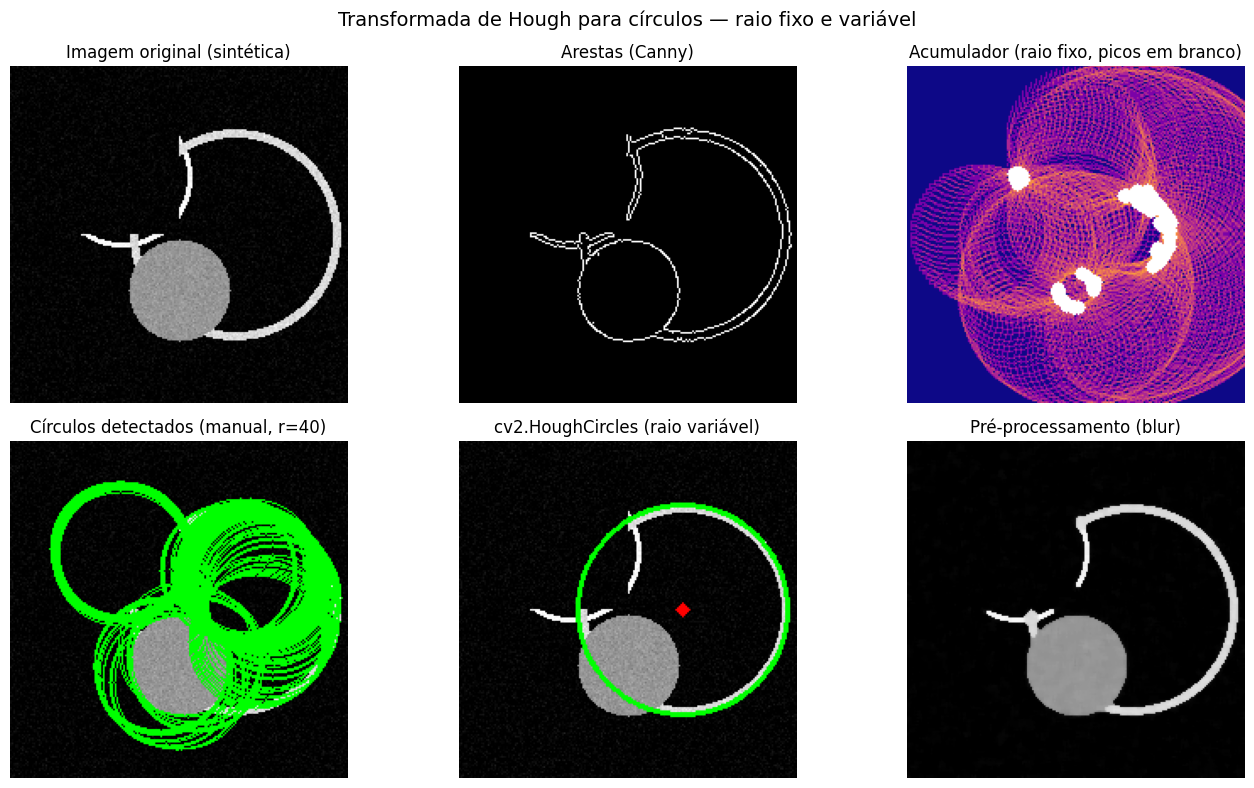

In [10]:
def synthesize_hough_circles(size=200, noise_sigma=10):
    img = np.zeros((size, size), dtype=np.uint8)
    cv2.circle(img, (size // 3, size // 3), 40, 255, 2)
    cv2.circle(img, (2 * size // 3, size // 2), 60, 220, 3)
    cv2.circle(img, (size // 2, 2 * size // 3), 30, 150, -1)
    img[:size // 2, :size // 2] = 0
    noise = np.random.normal(0, noise_sigma, (size, size))
    noisy = np.clip(img.astype(np.float32) + noise, 0, 255).astype(np.uint8)
    return noisy

def hough_circles_fixed(edge_img, radius):
    h, w = edge_img.shape
    accum = np.zeros((h, w), dtype=np.uint64)
    y_idxs, x_idxs = np.nonzero(edge_img)
    angles = np.deg2rad(np.arange(0, 360, 5))
    for x, y in zip(x_idxs, y_idxs):
        for angle in angles:
            a = int(x - radius * np.cos(angle))
            b = int(y - radius * np.sin(angle))
            if 0 <= a < w and 0 <= b < h:
                accum[b, a] += 1
    return accum

img_in = synthesize_hough_circles()
edges_circ = cv2.Canny(img_in, 100, 200)
acc_circ = hough_circles_fixed(edges_circ, 40)

acc_display = np.log1p(acc_circ)
acc_display /= acc_display.max()
acc_display = (acc_display * 255).astype(np.uint8)
acc_display = cv2.applyColorMap(acc_display, cv2.COLORMAP_PLASMA)

centers = np.argwhere(acc_circ > np.max(acc_circ) * 0.6)
img_manual = cv2.cvtColor(img_in, cv2.COLOR_GRAY2BGR)
for (cy, cx) in centers:
    cv2.circle(img_manual, (cx, cy), 40, (0, 255, 0), 1)
    cv2.circle(acc_display, (cx, cy), 4, (255, 255, 255), -1)

img_blur = cv2.medianBlur(img_in, 5)
circles_cv = cv2.HoughCircles(img_blur, cv2.HOUGH_GRADIENT, dp=1, minDist=30, 
                              param1=50, param2=30, minRadius=20, maxRadius=80)
img_cv = cv2.cvtColor(img_in, cv2.COLOR_GRAY2BGR)
if circles_cv is not None:
    circles_cv = np.round(circles_cv[0, :]).astype(int)
    for x_c, y_c, r in circles_cv:
        cv2.circle(img_cv, (x_c, y_c), r, (0, 255, 0), 2)
        cv2.circle(img_cv, (x_c, y_c), 2, (255, 0, 0), 3)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes[0, 0].imshow(img_in, cmap='gray')
axes[0, 0].set_title('Imagem original (sintética)')
axes[0, 0].axis('off')
axes[0, 1].imshow(edges_circ, cmap='gray')
axes[0, 1].set_title('Arestas (Canny)')
axes[0, 1].axis('off')
axes[0, 2].imshow(acc_display[..., ::-1])
axes[0, 2].set_title('Acumulador (raio fixo, picos em branco)')
axes[0, 2].axis('off')
axes[1, 0].imshow(img_manual)
axes[1, 0].set_title('Círculos detectados (manual, r=40)')
axes[1, 0].axis('off')
axes[1, 1].imshow(img_cv)
axes[1, 1].set_title('cv2.HoughCircles (raio variável)')
axes[1, 1].axis('off')
axes[1, 2].imshow(img_blur, cmap='gray')
axes[1, 2].set_title('Pré-processamento (blur)')
axes[1, 2].axis('off')
fig.suptitle('Transformada de Hough para círculos — raio fixo e variável', fontsize=14)
plt.tight_layout()
plt.show()

## 4.2.11. Contornos

Esta célula apresenta um exemplo clássico de **extração e análise de contornos** — um passo fundamental em tarefas de segmentação e reconhecimento de formas. São comparadas duas abordagens complementares:  
1) a detecção de contornos com o **OpenCV**, que oferece ferramentas rápidas e diretas para manipulação geométrica, e  
2) as funções analíticas do **scikit-image**, que facilitam a extração de propriedades e medições.

**Descrição sequencial do código**  
1) Carrega-se a imagem `coins` do `skimage.data`, convertida em tons de cinzento.  
2) Aplica-se uma **suavização Gaussiana** (`cv2.GaussianBlur`) para reduzir ruído e estabilizar as transições de borda.  
3) Executa-se o **detetor de Canny** (`cv2.Canny`) para realçar arestas.  
4) `cv2.findContours` identifica todos os **contornos externos** — cada contorno é uma lista ordenada de pontos $(x, y)$ que formam curvas fechadas em torno das regiões detectadas.  
5) `cv2.drawContours` desenha todos os contornos em verde sobre uma cópia da imagem original (`img_contours`).  
6) As **áreas dos contornos** são calculadas com `cv2.contourArea`, permitindo:
   - ordenar os contornos por tamanho;  
   - aplicar um filtro mínimo de área (`min_area = 50`) para eliminar ruído ou fragmentos insignificantes.  
7) Os contornos filtrados são desenhados a amarelo (`img_filtered`).  
8) Para cada contorno filtrado:
   - obtém-se o **retângulo delimitador** (`cv2.boundingRect`) e desenha-se a caixa em verde;  
   - calcula-se o **centróide** a partir dos momentos geométricos (`cv2.moments`) e marca-se com um ponto azul.  
9) Em paralelo, demonstra-se a extração com o **scikit-image**:
   - `measure.find_contours` devolve listas de coordenadas das curvas a nível de intensidade 0.5;  
   - `measure.label` e `regionprops` permitem obter **propriedades regionais** (área, perímetro, centroides, etc.);  
   - o resultado é visualizado com `color.label2rgb`.  
10) As figuras sintetizam as etapas:
    - (1,1) imagem original;  
    - (1,2) arestas;  
    - (1,3) todos os contornos detectados (OpenCV);  
    - (2,1) contornos filtrados por área;  
    - (2,2) caixas e centroides;  
    - (2,3) detecção e rotulagem pelo scikit-image.  
11) Por fim, imprime-se um pequeno resumo quantitativo:  
    - número total de contornos detectados e filtrados (OpenCV);  
    - número de contornos via `skimage`;  
    - média das áreas medidas pelas regiões rotuladas.

**Interpretação e observações**  
Este exercício evidencia duas perspectivas complementares:  
- **OpenCV** é eficiente na detecção e manipulação geométrica dos contornos (ideal para pós-processamento visual, bounding boxes, tracking).  
- **scikit-image** é mais analítico, fornecendo acesso a propriedades morfométricas (área, excentricidade, razão de eixos, etc.) úteis em análise quantitativa.  

A filtragem por área e o cálculo dos centroides são passos típicos em pipelines de segmentação, permitindo:  
- eliminar artefactos e ruído,  
- quantificar objetos,  
- e preparar os dados para medições ou classificações posteriores.  

Em resumo, a célula mostra como **detecção, filtragem e caracterização de contornos** formam a ponte entre a simples binarização e a **análise estrutural de objetos** — uma das fases-chave do processamento digital de imagens.

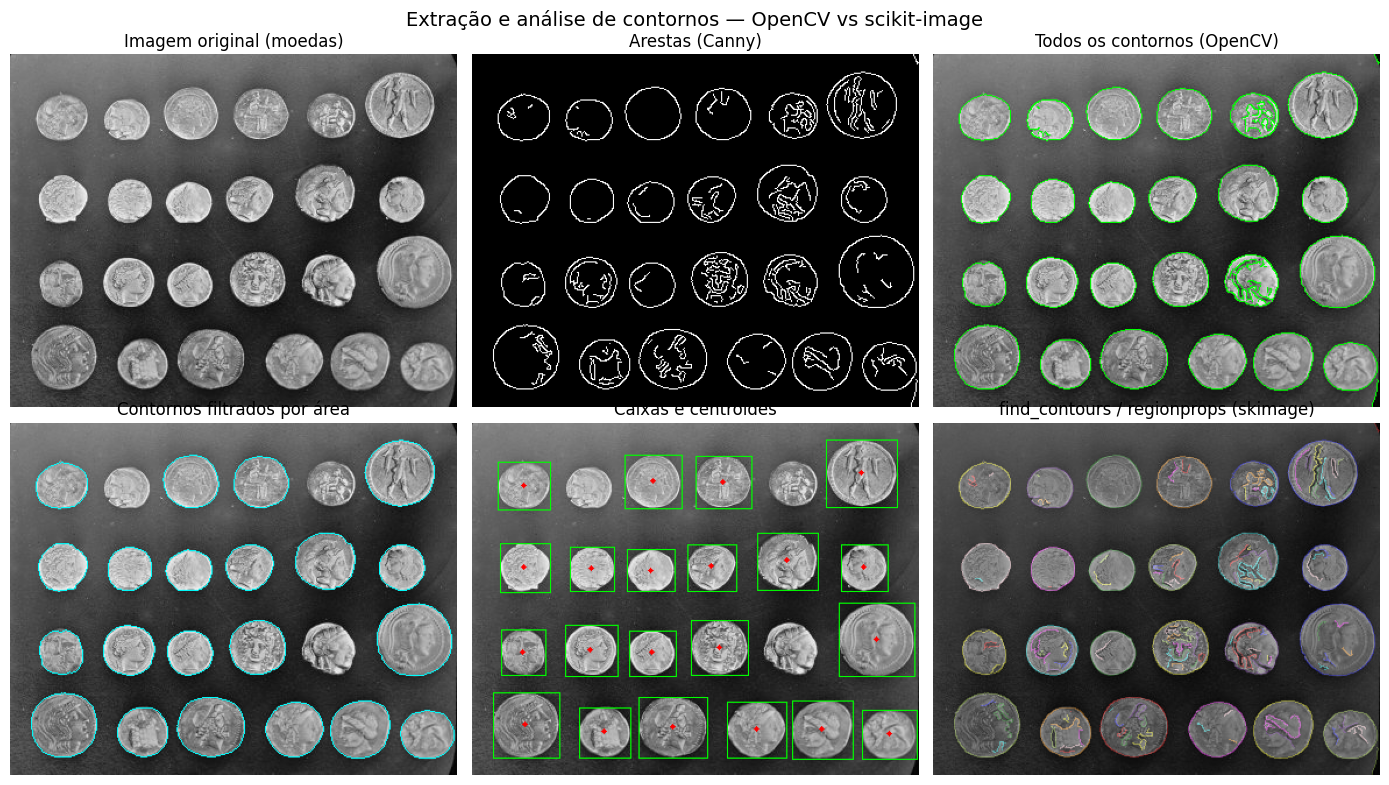

Total de contornos OpenCV: 40
Após filtragem: 21
Contornos via skimage: 905
Média de áreas (skimage): 57.23


In [11]:
img_in = img_coins
img_blur = cv2.GaussianBlur(img_in, (5, 5), 0)
edges = cv2.Canny(img_blur, 80, 160)

contours, hierarchy = cv2.findContours(edges.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

img_contours = cv2.cvtColor(img_in, cv2.COLOR_GRAY2BGR)
cv2.drawContours(img_contours, contours, -1, (0, 255, 0), 1)

areas = [cv2.contourArea(c) for c in contours]
contours_sorted = [c for c, a in sorted(zip(contours, areas), key=lambda ca: ca[1], reverse=True)]
min_area = 50
contours_filtered = [c for c in contours_sorted if cv2.contourArea(c) >= min_area]

img_filtered = cv2.cvtColor(img_in, cv2.COLOR_GRAY2BGR)
cv2.drawContours(img_filtered, contours_filtered, -1, (0, 255, 255), 1)

img_bbox = cv2.cvtColor(img_in, cv2.COLOR_GRAY2BGR)
centroids = []
for c in contours_filtered:
    x, y, w_b, h_b = cv2.boundingRect(c)
    cv2.rectangle(img_bbox, (x, y), (x + w_b, y + h_b), (0, 255, 0), 1)
    M = cv2.moments(c)
    if M['m00'] != 0:
        cx = int(M['m10'] / M['m00'])
        cy = int(M['m01'] / M['m00'])
        centroids.append((cx, cy))
        cv2.circle(img_bbox, (cx, cy), 2, (255, 0, 0), -1)

sk_contours = measure.find_contours(edges.astype(float) / 255.0, 0.5)
labels_sk = measure.label((edges > 0).astype(int))
props = measure.regionprops(labels_sk)
areas_sk = [p.area for p in props]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes[0, 0].imshow(img_in, cmap='gray')
axes[0, 0].set_title('Imagem original (moedas)')
axes[0, 0].axis('off')
axes[0, 1].imshow(edges, cmap='gray')
axes[0, 1].set_title('Arestas (Canny)')
axes[0, 1].axis('off')
axes[0, 2].imshow(img_contours)
axes[0, 2].set_title('Todos os contornos (OpenCV)')
axes[0, 2].axis('off')
axes[1, 0].imshow(img_filtered)
axes[1, 0].set_title('Contornos filtrados por área')
axes[1, 0].axis('off')
axes[1, 1].imshow(img_bbox)
axes[1, 1].set_title('Caixas e centroides')
axes[1, 1].axis('off')
axes[1, 2].imshow(color.label2rgb(labels_sk, image=img_in, bg_label=0))
axes[1, 2].set_title('find_contours / regionprops (skimage)')
axes[1, 2].axis('off')
fig.suptitle('Extração e análise de contornos — OpenCV vs scikit-image', fontsize=14)
plt.tight_layout()
plt.show()

print(f"Total de contornos OpenCV: {len(contours)}")
print(f"Após filtragem: {len(contours_filtered)}")
print(f"Contornos via skimage: {len(sk_contours)}")
print(f"Média de áreas (skimage): {np.mean(areas_sk):.2f}")

## 4.2.12. Comparação e Avaliação

Esta célula encerra o capítulo de **deteção de arestas** com uma comparação experimental entre quatro operadores clássicos — **Sobel, Prewitt, LoG e Canny** — analisando a sua **precisão, recall, robustez ao ruído e tempo de execução**.  
A avaliação é realizada sobre uma imagem sintética de referência com arestas conhecidas (“ground truth”), permitindo uma medição objetiva do desempenho.

**Descrição sequencial do código**  
1) Cria-se uma **imagem binária simples** com um quadrado branco sobre fundo preto, cujas bordas definem o *ground truth* (`gt_edges`).  
2) Cada operador é aplicado separadamente:
   - **Sobel** e **Prewitt**: convoluções manuais com máscaras derivativas horizontais e verticais, seguidas do cálculo da magnitude do gradiente e binarização pelo valor médio.  
   - **LoG** (Laplaciano do Gaussiano): convolução com máscara LoG e deteção de *zero-crossings*.  
   - **Canny**: versão OpenCV com histerese de limiares (50–150).  
3) Define-se uma função `evaluate(gt, pred)` que calcula **precisão** e **recall** com base na interseção de píxeis de aresta entre o resultado e o *ground truth*.  
4) As métricas de cada método são reunidas e apresentadas em gráficos:
   - Figura 1: comparação visual das detecções de arestas.  
   - Figura 2: gráfico de barras com precisão e recall por método.  
5) A seguir, estuda-se a **sensibilidade ao limiar** do Sobel:
   - Variando o limiar de 0.1 a 1.0 sobre a magnitude normalizada, observa-se como a precisão evolui (trade-off entre deteções verdadeiras e falsas).  
6) Depois, avalia-se a **robustez ao ruído** no método de Canny:
   - Adiciona-se ruído gaussiano de diferentes desvios padrão (0 a 40) à imagem original,  
   - Calculam-se novamente precisão e recall, traçando a degradação do desempenho.  
7) Por fim, mede-se o **tempo de execução médio** de cada método (em milissegundos) com funções dedicadas (`sobel_time`, `prewitt_time`, etc.) e apresenta-se num gráfico de barras.

**Interpretação e observações**  
Os resultados sintetizam as **características de cada operador**:

- **Sobel** e **Prewitt** produzem resultados semelhantes, sendo rápidos e adequados para detecção geral de bordas, mas sensíveis ao ruído e à escolha de limiar.  
- **LoG** é mais preciso na definição das arestas verdadeiras, mas computacionalmente mais pesado.  
- **Canny** combina filtragem, gradiente e histerese, obtendo melhor equilíbrio entre **precisão** e **robustez**, mesmo sob ruído elevado.  

Em termos quantitativos:
- **Precisão** mede a pureza das detecções (quantos píxeis de aresta detetados são verdadeiros);  
- **Recall** mede a completude (quantas arestas verdadeiras foram encontradas).  
O equilíbrio entre ambos é essencial para aplicações reais.

O gráfico de tempos mostra a diferença de complexidade — os métodos baseados em convolução simples são muito mais rápidos, enquanto o LoG e o Canny implicam várias etapas de filtragem.  

Em resumo, esta célula transforma o estudo qualitativo em **análise quantitativa comparativa**, evidenciando:
- as compensações entre precisão, robustez e custo computacional;  
- e a importância da escolha criteriosa do operador conforme o contexto (análise estrutural, visão robótica, pré-processamento, etc.).

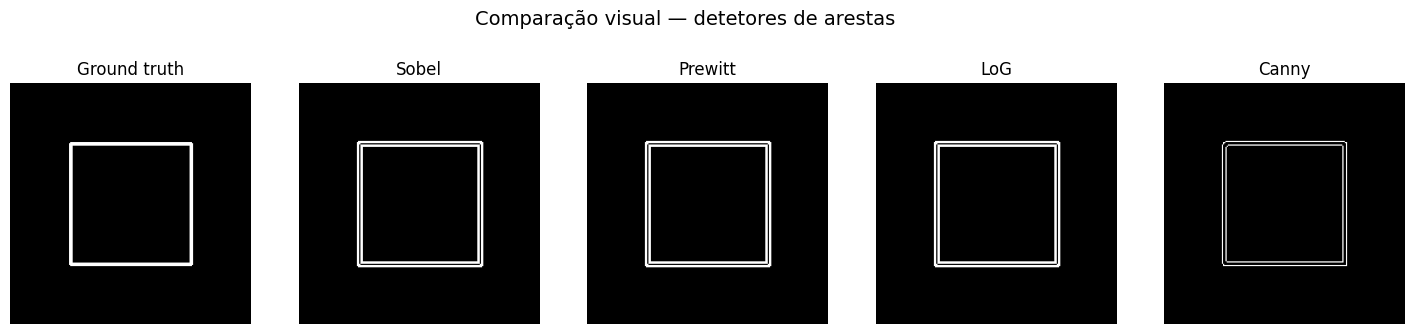

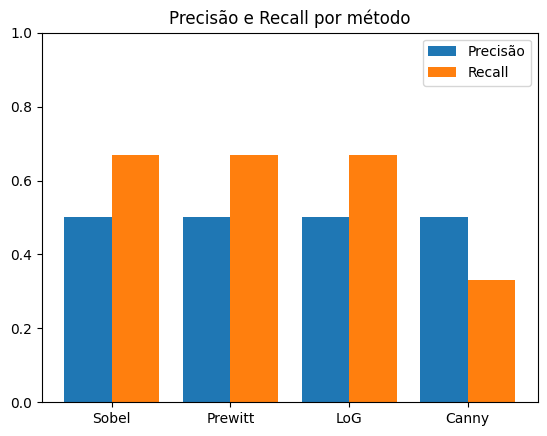

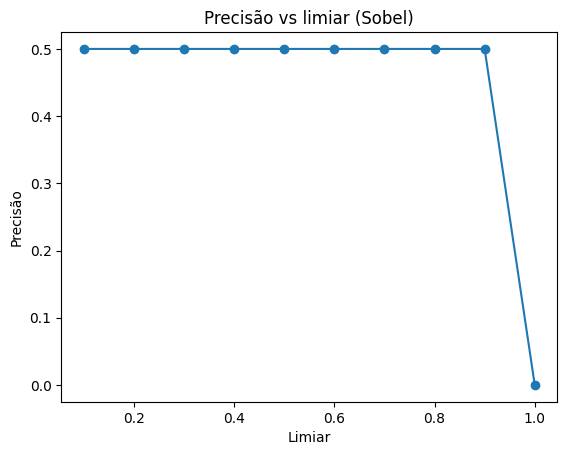

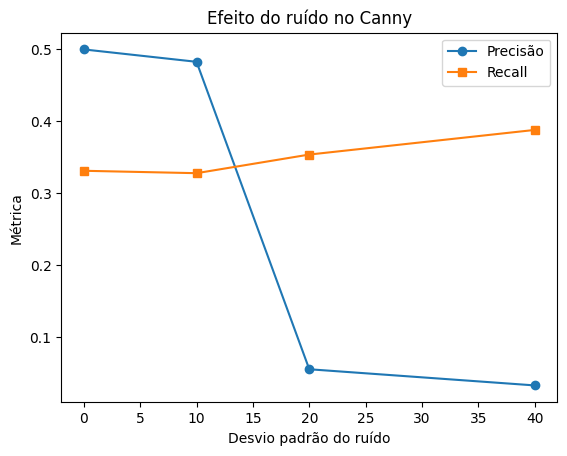

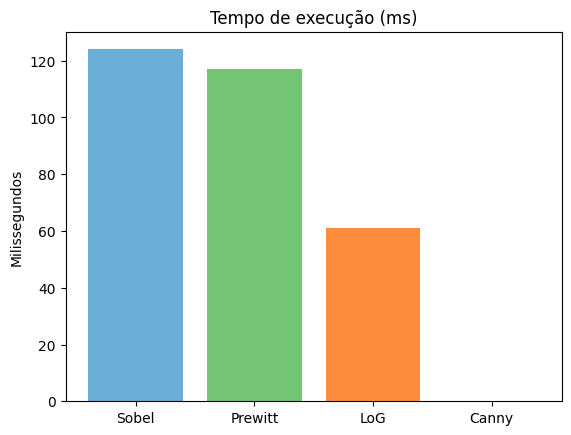

In [12]:
ref_img = img_rect
gt_edges = ref_img.copy()

sobel_ref_gx = convolve2d_manual(ref_img.astype(float), sobel_x)
sobel_ref_gy = convolve2d_manual(ref_img.astype(float), sobel_y)
sobel_ref_mag = np.hypot(sobel_ref_gx, sobel_ref_gy)
sobel_ref_edges = (sobel_ref_mag > sobel_ref_mag.mean()).astype(np.uint8)

prew_ref_gx = convolve2d_manual(ref_img.astype(float), prewitt_x)
prew_ref_gy = convolve2d_manual(ref_img.astype(float), prewitt_y)
prew_ref_mag = np.hypot(prew_ref_gx, prew_ref_gy)
prew_ref_edges = (prew_ref_mag > prew_ref_mag.mean()).astype(np.uint8)

log_ref = convolve2d_manual(ref_img.astype(float), log_mask)
log_ref_edges = np.zeros_like(ref_img, dtype=np.uint8)
for i in range(1, ref_img.shape[0] - 1):
    for j in range(1, ref_img.shape[1] - 1):
        patch = log_ref[i - 1:i + 2, j - 1:j + 2]
        if patch.min() < 0 and patch.max() > 0:
            log_ref_edges[i, j] = 1

canny_ref = cv2.Canny(ref_img, 50, 150)

def evaluate(gt, pred):
    tp = np.sum((gt > 0) & (pred > 0))
    fp = np.sum((gt == 0) & (pred > 0))
    fn = np.sum((gt > 0) & (pred == 0))
    prec = tp / (tp + fp + 1e-8)
    rec = tp / (tp + fn + 1e-8)
    return prec, rec

methods = {
    'Sobel': sobel_ref_edges,
    'Prewitt': prew_ref_edges,
    'LoG': log_ref_edges,
    'Canny': (canny_ref > 0).astype(np.uint8)
}
metrics = {m: evaluate(gt_edges, pred) for m, pred in methods.items()}

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
axes[0].imshow(gt_edges, cmap='gray')
axes[0].set_title('Ground truth')
axes[0].axis('off')
for ax, (m, pred) in zip(axes[1:], methods.items()):
    ax.imshow(pred, cmap='gray')
    ax.set_title(m)
    ax.axis('off')
fig.suptitle('Comparação visual — detetores de arestas', fontsize=14)
plt.show()

precisions = [metrics[m][0] for m in methods]
recalls = [metrics[m][1] for m in methods]
x = np.arange(len(methods))
fig, ax = plt.subplots()
ax.bar(x - 0.2, precisions, width=0.4, label='Precisão')
ax.bar(x + 0.2, recalls, width=0.4, label='Recall')
ax.set_xticks(x)
ax.set_xticklabels(methods.keys())
ax.set_ylim(0, 1)
ax.set_title('Precisão e Recall por método')
ax.legend()

thresholds_range = np.linspace(0.1, 1.0, 10)
precisions_thr = []
sob_mag_norm = sobel_ref_mag / (sobel_ref_mag.max() + 1e-8)
for thr in thresholds_range:
    pred = (sob_mag_norm > thr).astype(np.uint8)
    prec, rec = evaluate(gt_edges, pred)
    precisions_thr.append(prec)
fig, ax = plt.subplots()
ax.plot(thresholds_range, precisions_thr, marker='o')
ax.set_title('Precisão vs limiar (Sobel)')
ax.set_xlabel('Limiar')
ax.set_ylabel('Precisão')

noise_std_vals = [0, 10, 20, 40]
precision_noise = []
recall_noise = []
for s in noise_std_vals:
    noisy_ref = (ref_img.astype(np.float32) + np.random.normal(0, s, ref_img.shape)).clip(0, 255).astype(np.uint8)
    edges_noisy = cv2.Canny(noisy_ref, 50, 150)
    prec, rec = evaluate(gt_edges, (edges_noisy > 0).astype(np.uint8))
    precision_noise.append(prec)
    recall_noise.append(rec)
fig, ax = plt.subplots()
ax.plot(noise_std_vals, precision_noise, label='Precisão', marker='o')
ax.plot(noise_std_vals, recall_noise, label='Recall', marker='s')
ax.set_title('Efeito do ruído no Canny')
ax.set_xlabel('Desvio padrão do ruído')
ax.set_ylabel('Métrica')
ax.legend()

def time_function(func):
    start = time.perf_counter()
    func()
    return (time.perf_counter() - start) * 1000

def sobel_time():
    gx = convolve2d_manual(ref_img.astype(float), sobel_x)
    gy = convolve2d_manual(ref_img.astype(float), sobel_y)
    np.hypot(gx, gy)
def prewitt_time():
    gx = convolve2d_manual(ref_img.astype(float), prewitt_x)
    gy = convolve2d_manual(ref_img.astype(float), prewitt_y)
    np.hypot(gx, gy)
def log_time():
    convolve2d_manual(ref_img.astype(float), log_mask)
def canny_time():
    cv2.Canny(ref_img, 50, 150)

times = {
    'Sobel': time_function(sobel_time),
    'Prewitt': time_function(prewitt_time),
    'LoG': time_function(log_time),
    'Canny': time_function(canny_time)
}

fig, ax = plt.subplots()
ax.bar(times.keys(), times.values(), color=['#6baed6', '#74c476', '#fd8d3c', '#e34a33'])
ax.set_title('Tempo de execução (ms)')
ax.set_ylabel('Milissegundos')
plt.show()

## 4.2.13. Funções Úteis

Definimos uma função utilitária que, dada uma imagem, aplica diferentes detectores de contornos (Sobel, Canny, LoG) e apresenta os resultados lado a lado. Isto permite ao utilizador comparar rapidamente o desempenho visual de cada método numa mesma imagem. Parâmetros internos como os limiares podem ser ajustados para cada detector.

In [13]:
def compare_edges(img, methods=['sobel', 'canny', 'log']):
    fig, axes = plt.subplots(1, len(methods), figsize=(5 * len(methods), 4))
    for idx, method in enumerate(methods):
        if method == 'sobel':
            gx = cv2.Sobel(img.astype(np.float32), cv2.CV_64F, 1, 0)
            gy = cv2.Sobel(img.astype(np.float32), cv2.CV_64F, 0, 1)
            mag = np.hypot(gx, gy)
            edges = (mag > mag.mean()).astype(np.uint8) * 255
        elif method == 'canny':
            edges = cv2.Canny(img, 100, 200)
        elif method == 'log':
            gauss = gaussian_filter(img.astype(np.float32), sigma=1)
            lap = cv2.Laplacian(gauss, cv2.CV_64F)
            zero = np.zeros_like(img, dtype=np.uint8)
            for i in range(1, img.shape[0] - 1):
                for j in range(1, img.shape[1] - 1):
                    patch = lap[i - 1:i + 2, j - 1:j + 2]
                    if patch.min() < 0 and patch.max() > 0:
                        zero[i, j] = 255
            edges = zero
        axes[idx].imshow(edges, cmap='gray')
        axes[idx].set_title(method)
        axes[idx].axis('off')

def plot_gradients(Gx, Gy, step=10):
    y, x = np.mgrid[0:Gx.shape[0]:step, 0:Gx.shape[1]:step]
    u = Gx[::step, ::step]
    v = -Gy[::step, ::step]
    fig, ax = plt.subplots()
    ax.imshow(np.zeros_like(Gx), cmap='gray')
    ax.quiver(x, y, u, v, color='red', angles='xy', scale_units='xy', scale=1)
    ax.set_title('Campo de gradientes')
    ax.axis('off')

def accumulator_view(H):
    H_norm = H.astype(np.float32)
    if H_norm.max() > 0:
        H_norm = H_norm / H_norm.max()
    fig, ax = plt.subplots()
    ax.imshow(H_norm, cmap='inferno')
    ax.set_title('Acumulador normalizado')
    ax.axis('off')

def synthesize_lines_image(size=200):
    img = np.zeros((size, size), dtype=np.uint8)
    cv2.line(img, (0, int(size * 0.3)), (size - 1, int(size * 0.6)), 255, 2)
    cv2.line(img, (0, int(size * 0.6)), (size - 1, int(size * 0.3)), 200, 3)
    cv2.line(img, (int(size * 0.2), 0), (int(size * 0.8), size - 1), 150, 1)
    noise = np.random.normal(0, 20, (size, size))
    noisy = np.clip(img.astype(np.float32) + noise, 0, 255).astype(np.uint8)
    return noisy
